# This notebook regroups the code around graph formation/estimation -AKM estimator with MF at MANY DIMENSIONS-

Ce notebook reprend le même cheminement que le Notebook "clustering_AKM_MF_1D" avec cette fois des EF multi-dimensionnels 

## Packages and Import

In [194]:
#!pip install seaborn
#!pip install pandas
#!pip install matplotlib
#!pip install scikit-learn
#!pip install bipartitepandas
#!pip install umap-learn
#!pip install pacmap==0.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 46.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for annoy: filename=annoy-1.17.3-cp312-cp312-linux_x86_64.whl size=78865 sha256=a6cd6c7cbcf22620e59902e2a699e926751541ca3bed435ba523ff7314e13a90
  Stored in directory: /home/onyxia/.cache/pip/wheels/db/b9/53/a3b2d1fe1743abadddec6aa541294b24fdbc39d7800bc57311
Successfully built annoy


In [1]:
# bibliothéques fondamentales
import matplotlib.pyplot as plt
import pandas as pd
#import bipartitepandas as bpd
import numpy as np
import time
import random
pd.options.mode.chained_assignment = None  # default='warn' # Remove copy on slice warning

# Pour faire du ML/DL
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
from sklearn.preprocessing import LabelEncoder
simplefilter("ignore", category=ConvergenceWarning) # Useful for logistic regression

from tensorflow.keras.layers import Input, Dot, Embedding, Add, Flatten, Activation, Layer # Optimisation via tensorflow.keras
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import Callback

pd.options.mode.chained_assignment = None  # default='warn' # Remove copy on slice warning
import tensorflow as tf
from keras import regularizers
from sklearn.metrics import precision_score, recall_score, f1_score, mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # Confusion Matrix

# Pour visualisation/ réduction de dimension
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap
import pacmap
import seaborn as sns
# Clustering
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn import metrics

# Pour stocker un tuple
import pickle

# Pour calcul de similarité entre les matrices
from numpy.linalg import norm
from sklearn.metrics.pairwise import cosine_similarity

# Afficher un cercle autour d'un point
import matplotlib.patches as patches

# Pour rafraichir les scripts des modules sans redémarrer le kernel
import importlib

# Pour compter le temps d'exécution d'une fonction
import time

2024-09-09 12:41:21.250954: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-09-09 12:41:21.253015: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-09-09 12:41:21.258680: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-09-09 12:41:21.273090: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-09 12:41:21.296701: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been 

In [2]:
# module maison
import script.decorateur as decorateur
import script.graph_formation as graph_formation
import script.MF_NRS as MF_NRS
import script.simulation as simulation
import script.metrique as metrique
import script.animation as animation
import script.plot_functions as plot_functions

# importe la classe directement
GraphFormation = graph_formation.GraphFormation
get_estimations = MF_NRS.get_estimations


# Recharge les modules (A executer en cas de modification des scripts, cela permet d'éviter de restart le kernel)
importlib.reload(decorateur)
importlib.reload(graph_formation)
importlib.reload(MF_NRS)
importlib.reload(simulation)
importlib.reload(metrique)
importlib.reload(animation)
importlib.reload(plot_functions)

<module 'script.plot_functions' from '/home/onyxia/work/G4H_AKM_RS_NRS/script/plot_functions.py'>

## 2D case

### Formation du graphe

Les lignes de codes suivantes génèrent un graphe biparti entre des patients et des docteurs dont les liens $Y_{ij}$ (vaut 1 s'il y a un lien entre i et j, 0 sinon) suivent un modèle AKM $\textcolor{red}{généralisé}$, c'est-à-dire la loi suivante:

$$P(Y_{ij} = 1 | X_{ij}) = (1 + e^{-T})^{-1}$$         
où    $T =  \textcolor{red}{<\alpha_{i} | \psi_{j} > }+ X_{ij}\beta$ 

NB: Ceci implique que les EF des docteurs et des patients soient de même taille.

Les EF ne sont désormais plus simplement des scalaires mais bien des vecteurs.

Les lois des alphas et des psi sont ajustées pour une version 2D. Les paramètres de dilatations sont mis à 1.5 afin d'atteindre un densité autour de 10-13%.  Les autres paramètres par défaut resteront inchangés par rapport à la version 1D

In [9]:
#Exemple de foramtion de graphe avec des EF 2D
alpha_law_means = [[0,1], [1,-1], [2,0]]
psi_law_means = [[1,1], [1,-1], [-1,2]]
identity_matrices = np.array([np.eye(2) for _ in range(3)])


graph_object= GraphFormation(
                    n_patients=1000,
                     n_doctors=50,
                     max_number_connections=50,
                    beta_distance_graph = -20,
                    dilatation_p = 1.5,
                    dilatation_d = 1.5,
                    alpha_law_means = alpha_law_means,
                    psi_law_means = psi_law_means,
                    psi_law_stds= identity_matrices,
                    alpha_law_stds = identity_matrices,
                    std_multiplier_p=0,
                    std_multiplier_d=0,
                    nb_latent_factors=2)
graph_object.do_the_graph()
print(f"density of the graph: {graph_object.density*100:.2f}%")

density of the graph: 11.18%


### Etude préléminaires

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Mean Squared Error sur l'échantillon de test : 0.353838138467548
Precision: 0.71
Recall: 0.63
F1-score: 0.67
ESTIMATION BETA: X p [0.11374393]; X d [0.3594617]; D_p [1.4837492]; D_d [1.601286]; distance [-16.638412]
ERROR ESTIMATION BETA: X p [-0.08625607]; X d [0.15946169]; D_p [0.48374915]; D_d [0.60128605]; distance [3.3615875]


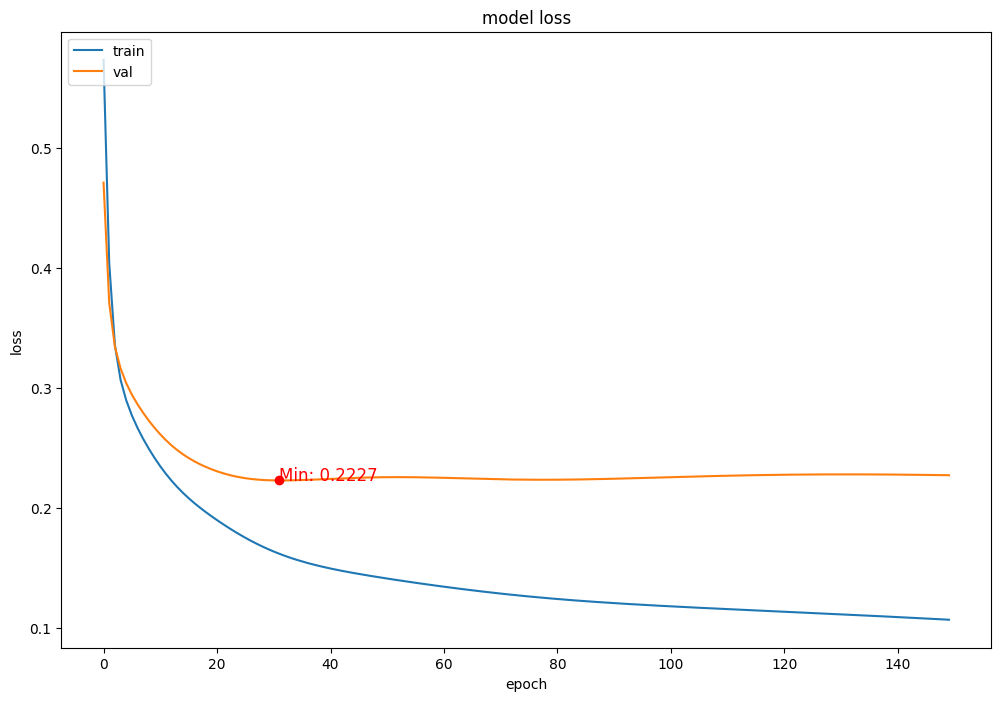

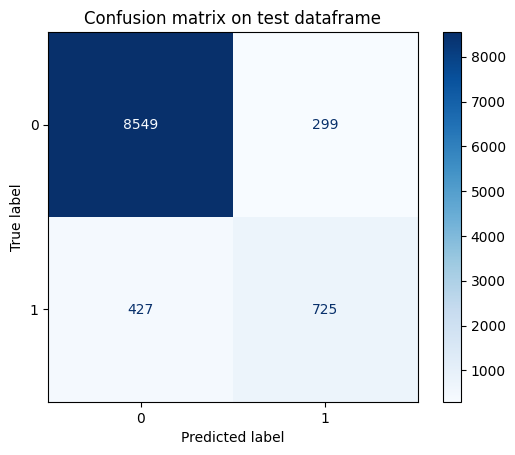

Temps d'exécution : 228 secondes


In [11]:
#Temps d'exécution : 285 secondes
MF_NRS.prediction_score(graph_object, dim_embedding=2, nb_epochs=150,)

density of the graph: 7.76%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Mean Squared Error sur l'échantillon de test : 0.2662933495428968
Precision: 0.65
Recall: 0.58
F1-score: 0.62
ESTIMATION BETA: X p [0.24057728]; X d [0.6516341]; D_p [1.7080193]; D_d [1.5656257]; distance [-20.599682]
ERROR ESTIMATION BETA: X p [0.04057728]; X d [0.4516341]; D_p [0.70801926]; D_d [0.56562567]; distance [4.400318]


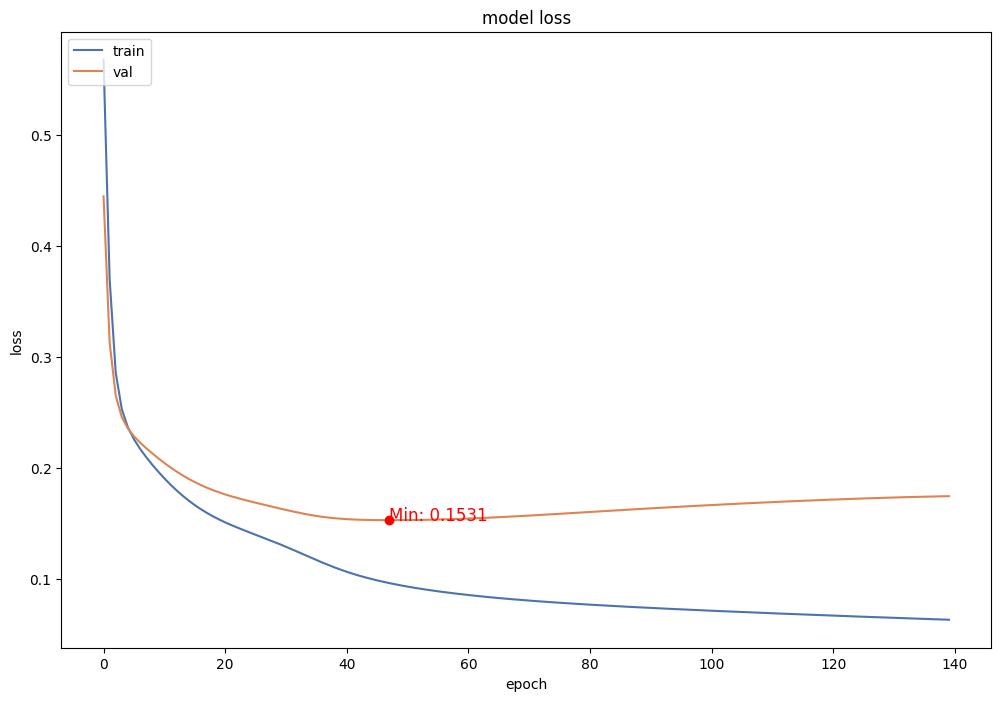

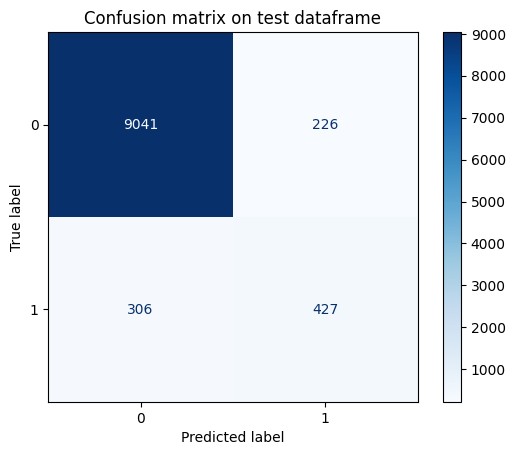

Temps d'exécution : 221 secondes
density of the graph: 14.54%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Mean Squared Error sur l'échantillon de test : 0.4399672271549261
Precision: 0.73
Recall: 0.61
F1-score: 0.66
ESTIMATION BETA: X p [0.11658502]; X d [0.36132225]; D_p [1.1833593]; D_d [1.6086202]; distance [-12.471829]
ERROR ESTIMATION BETA: X p [-0.08341498]; X d [0.16132225]; D_p [0.18335927]; D_d [0.60862017]; distance [4.5281706]


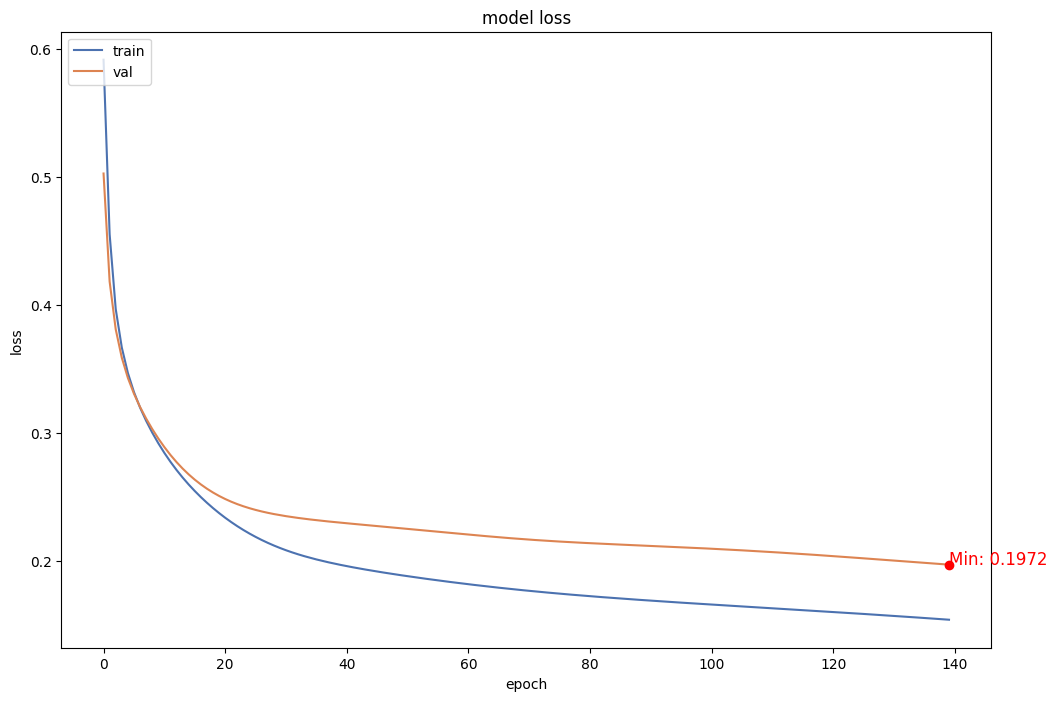

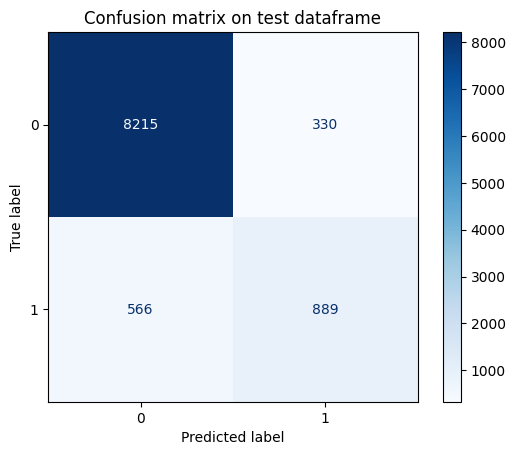

Temps d'exécution : 218 secondes
density of the graph: 21.94%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Mean Squared Error sur l'échantillon de test : 0.45958731686867405
Precision: 0.79
Recall: 0.75
F1-score: 0.77
ESTIMATION BETA: X p [0.13382646]; X d [0.43570146]; D_p [1.4879764]; D_d [1.453943]; distance [-13.178545]
ERROR ESTIMATION BETA: X p [-0.06617354]; X d [0.23570146]; D_p [0.48797643]; D_d [0.453943]; distance [-0.178545]


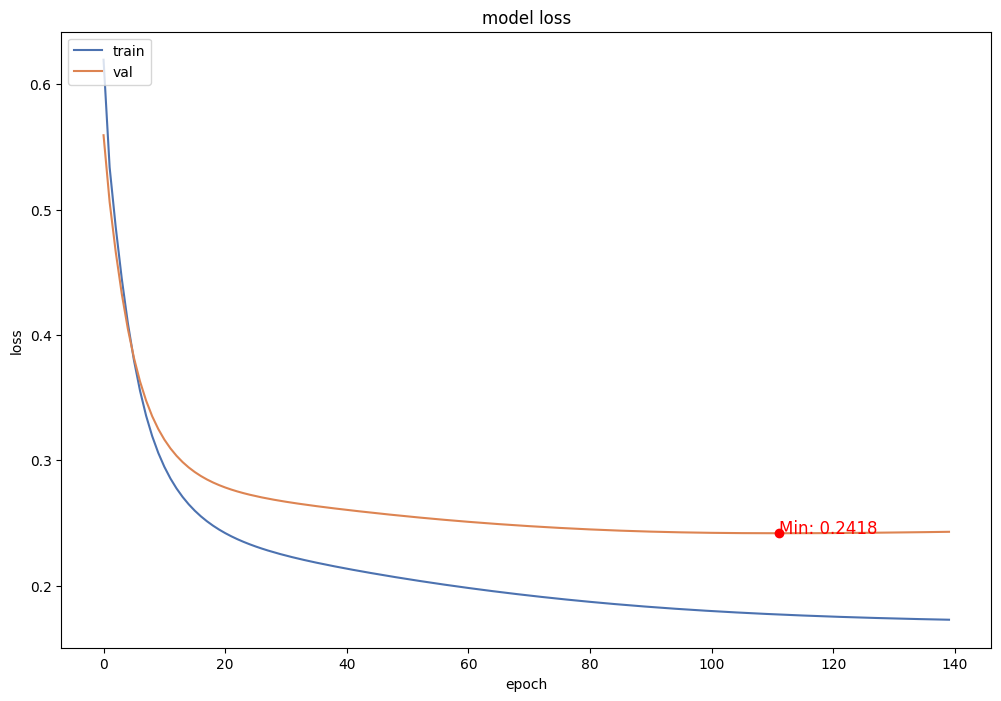

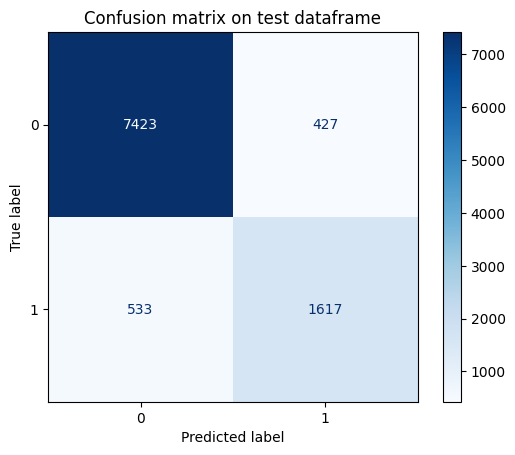

Temps d'exécution : 217 secondes
density of the graph: 31.29%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Mean Squared Error sur l'échantillon de test : 0.6181172289966809
Precision: 0.81
Recall: 0.78
F1-score: 0.79
ESTIMATION BETA: X p [0.1290401]; X d [0.23654279]; D_p [1.3232961]; D_d [1.6837555]; distance [-10.465549]
ERROR ESTIMATION BETA: X p [-0.0709599]; X d [0.03654279]; D_p [0.32329607]; D_d [0.6837555]; distance [-0.46554947]


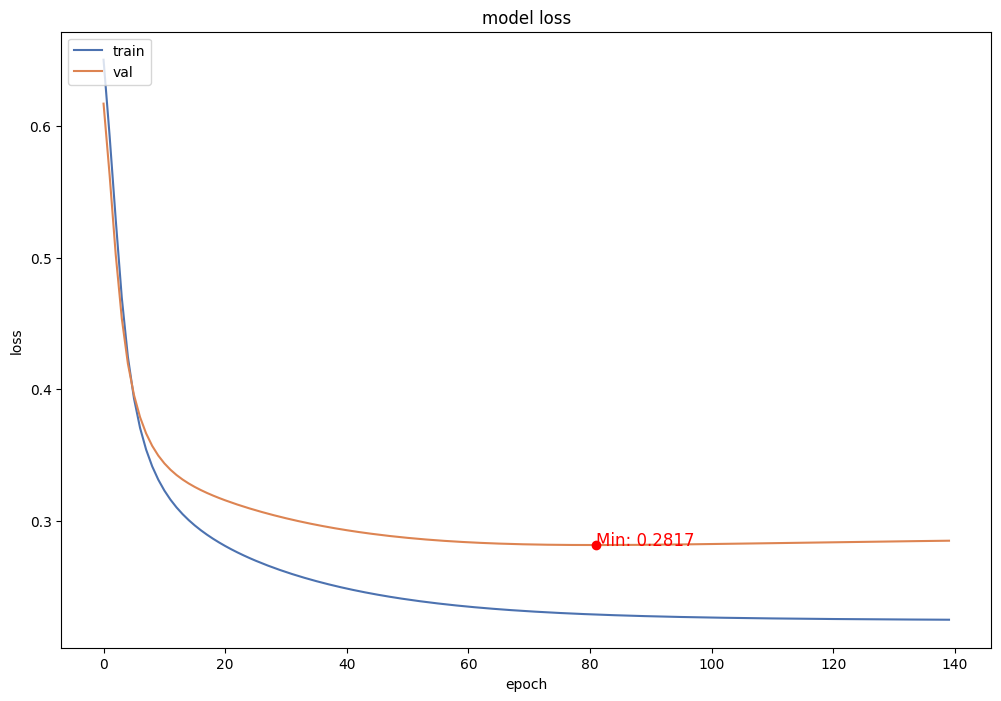

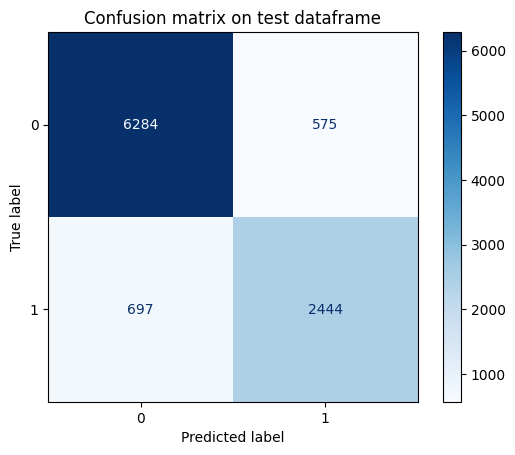

Temps d'exécution : 215 secondes
density of the graph: 40.31%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Mean Squared Error sur l'échantillon de test : 0.6478329875208354
Precision: 0.82
Recall: 0.84
F1-score: 0.83
ESTIMATION BETA: X p [0.3171943]; X d [0.30244327]; D_p [1.4142101]; D_d [1.3520303]; distance [-7.986348]
ERROR ESTIMATION BETA: X p [0.11719431]; X d [0.10244326]; D_p [0.41421008]; D_d [0.35203028]; distance [0.01365185]


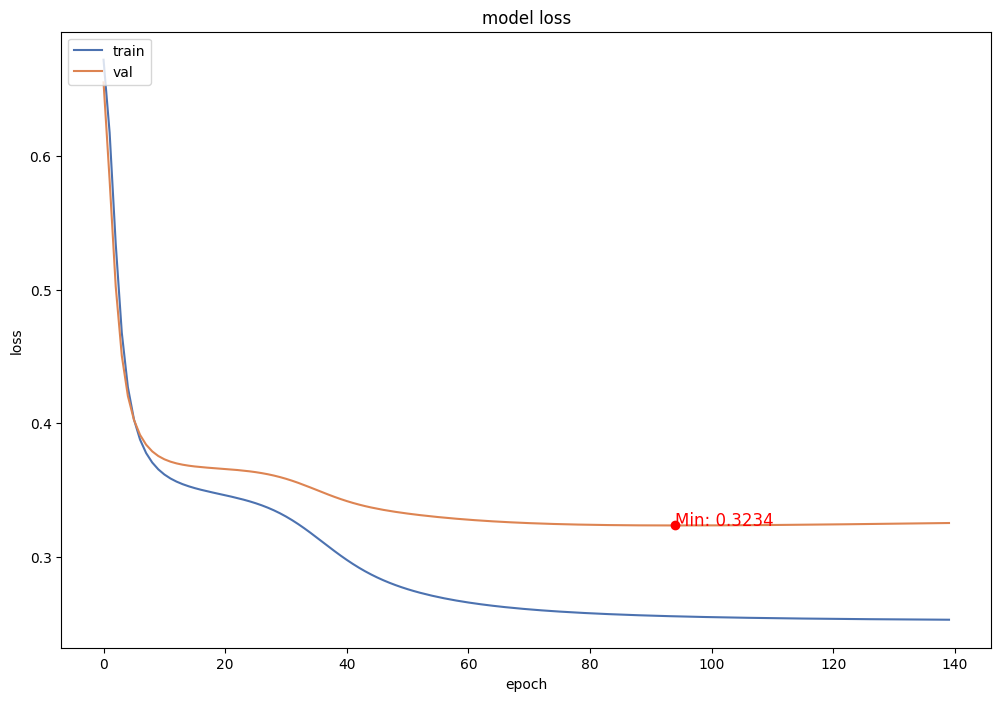

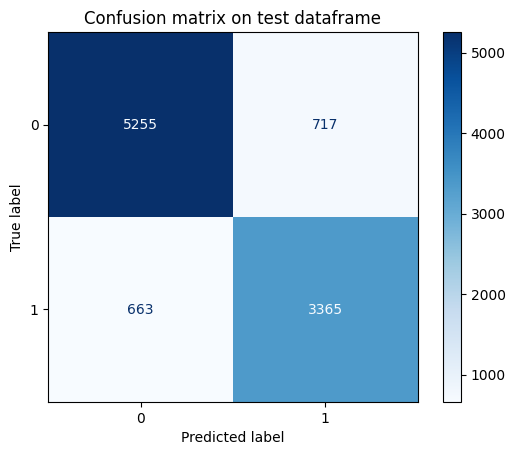

Temps d'exécution : 217 secondes
density of the graph: 55.03%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Mean Squared Error sur l'échantillon de test : 0.5610122557218161
Precision: 0.89
Recall: 0.91
F1-score: 0.90
ESTIMATION BETA: X p [0.17385209]; X d [0.26326182]; D_p [1.399012]; D_d [1.315499]; distance [-4.80027]
ERROR ESTIMATION BETA: X p [-0.02614792]; X d [0.06326182]; D_p [0.39901197]; D_d [0.31549895]; distance [0.19972992]


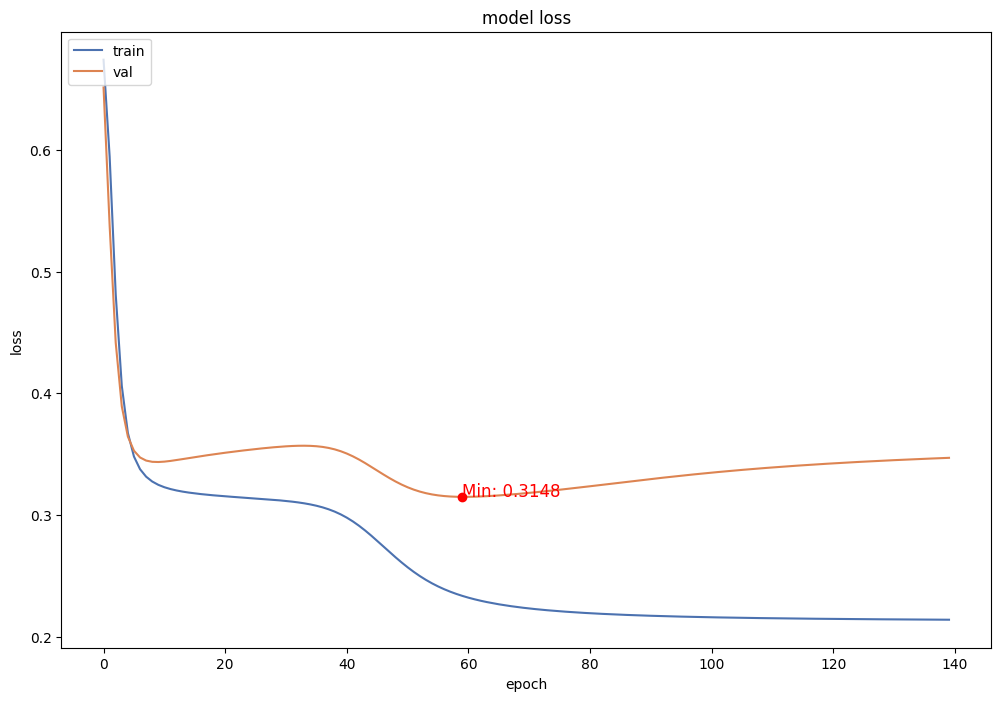

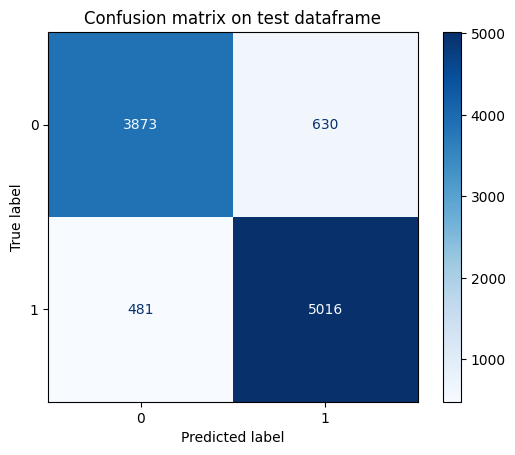

Temps d'exécution : 213 secondes
density of the graph: 62.73%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Mean Squared Error sur l'échantillon de test : 0.41306720286705423
Precision: 0.93
Recall: 0.94
F1-score: 0.94
ESTIMATION BETA: X p [0.20570678]; X d [0.36557215]; D_p [1.4020194]; D_d [1.24396]; distance [-2.641719]
ERROR ESTIMATION BETA: X p [0.00570677]; X d [0.16557215]; D_p [0.40201938]; D_d [0.24396002]; distance [0.3582809]


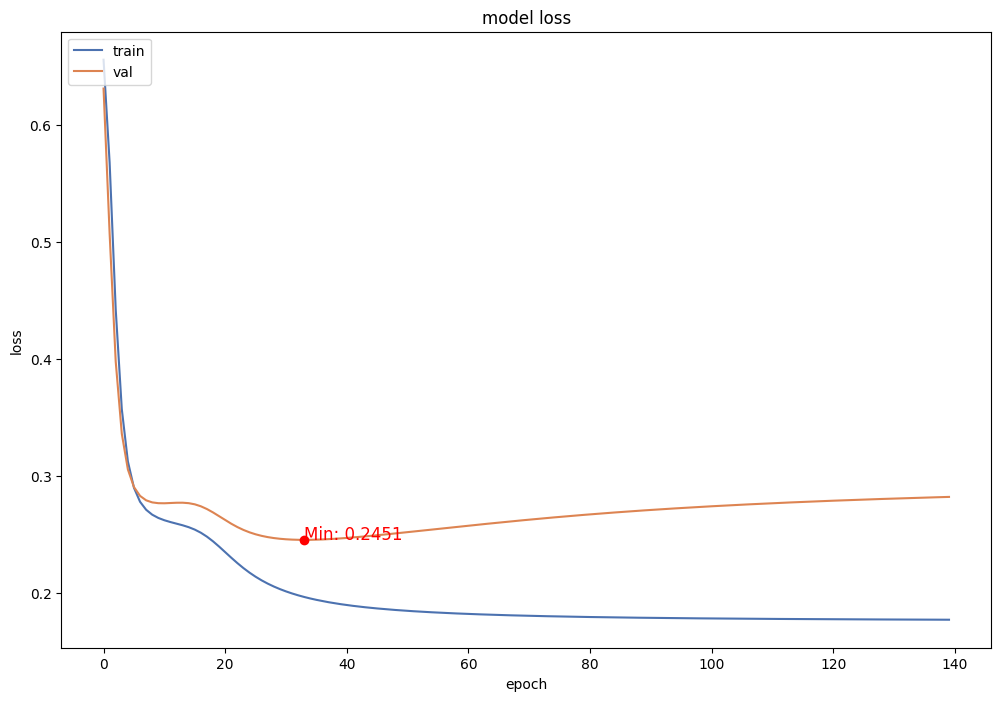

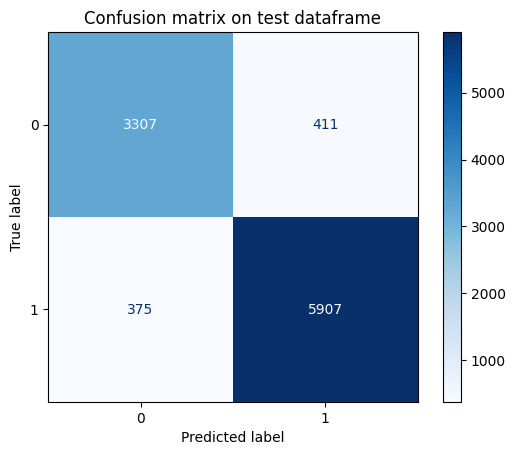

Temps d'exécution : 224 secondes
Temps d'exécution : 1528 secondes


In [68]:
MF_NRS.loss_vs_density(sim_beta_distance_array = [-25,-17, -13,-10, -8, -5,-3], 
                       nb_epochs=140, 
                       alpha_law_means=[[0,1], [1,-1], [2,0]],
                       psi_law_means= [[1,1], [1,-1], [-1,2]], 
                       std_multiplier_p=0, 
                       std_multiplier_d=0, 
                       nb_latent_factors=2,  
                       dilatation_p=1.5, 
                       dilatation_d = 1.5)

Il faut considérer désormais un nouveau RMSE:

$ RMSE_{\alpha,\psi,multiD} = [ \sum_{i,j} (<\alpha_{i}|\psi_{j}> - <\hat{\alpha_{i}}| \hat{\psi_{j}}> )^{2}]^{\frac{1}{2}} $

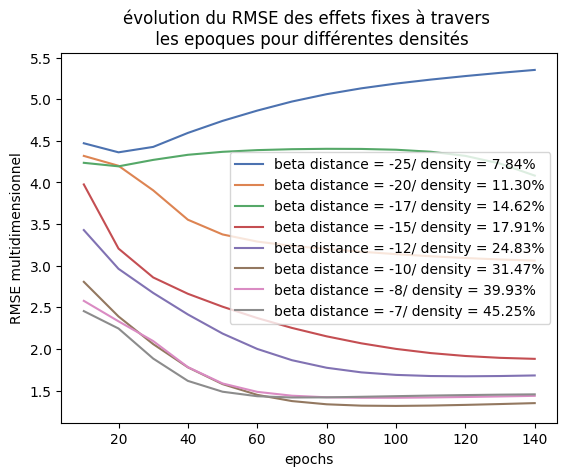

Temps d'exécution : 2344 secondes


In [49]:
# Temps d'exécution : 2344 secondes
density_ami_rmse_simulation.plot_rmse_epochs_multiD(n=14, save=True)

### Visualisation

In [15]:
#Exemple de foramtion de graphe avec des EF 2D
alpha_law_means = [[0,1], [1,-1], [2,0]]
psi_law_means = [[1,1], [1,-1], [-1,2]]

identity_matrices = np.array([np.eye(2) for _ in range(3)])


graph_object= GraphFormation(
                    n_patients=1000,
                     n_doctors=50,
                     max_number_connections=50,
                    beta_distance_graph = -20,
                    dilatation_p = 1.5,
                    dilatation_d = 1.5,
                    alpha_law_means = alpha_law_means,
                    psi_law_means = psi_law_means,
                    psi_law_stds= identity_matrices,
                    alpha_law_stds = identity_matrices,
                    std_multiplier_p=0,
                    std_multiplier_d=0,
                    nb_latent_factors=2)
graph_object.do_the_graph()
print(f"density of the graph: {graph_object.density*100:.2f}%")

density of the graph: 11.23%


#### Histogrammes des degrés

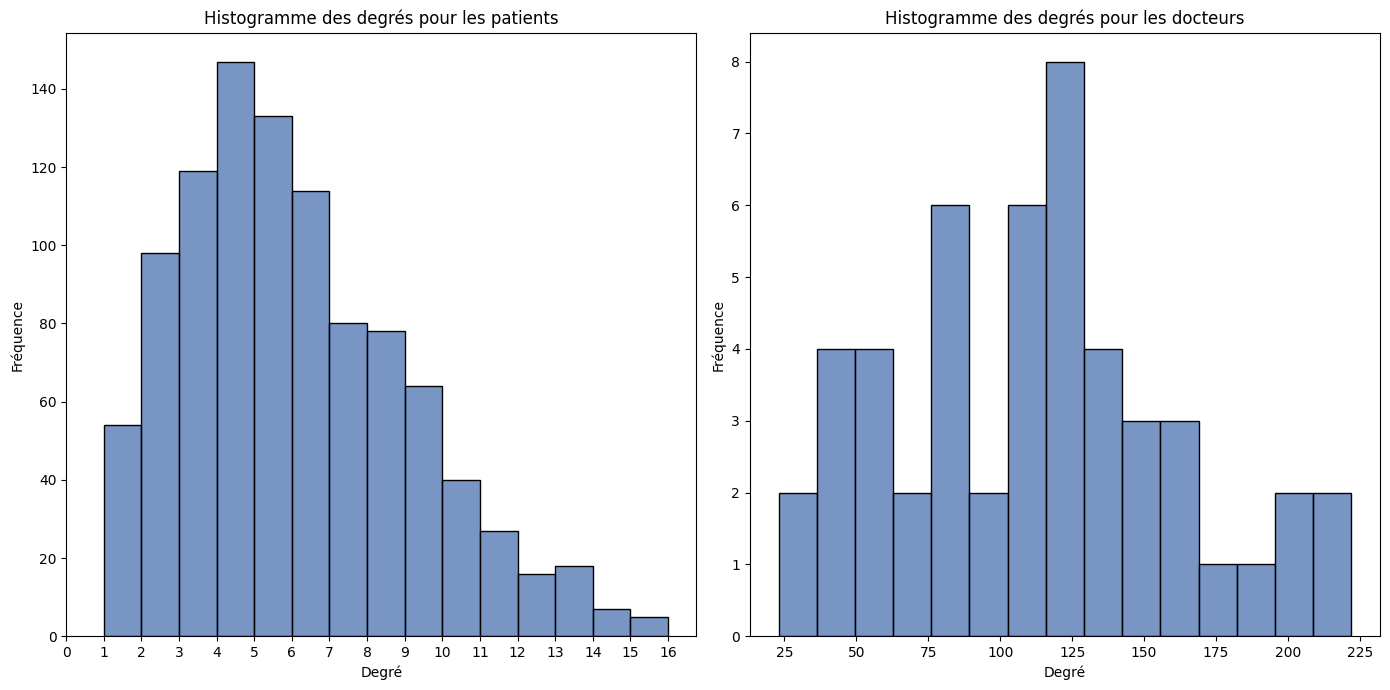

In [75]:
plot_functions.plot_hist_degree(graph_object, hue_class = False, save = False)

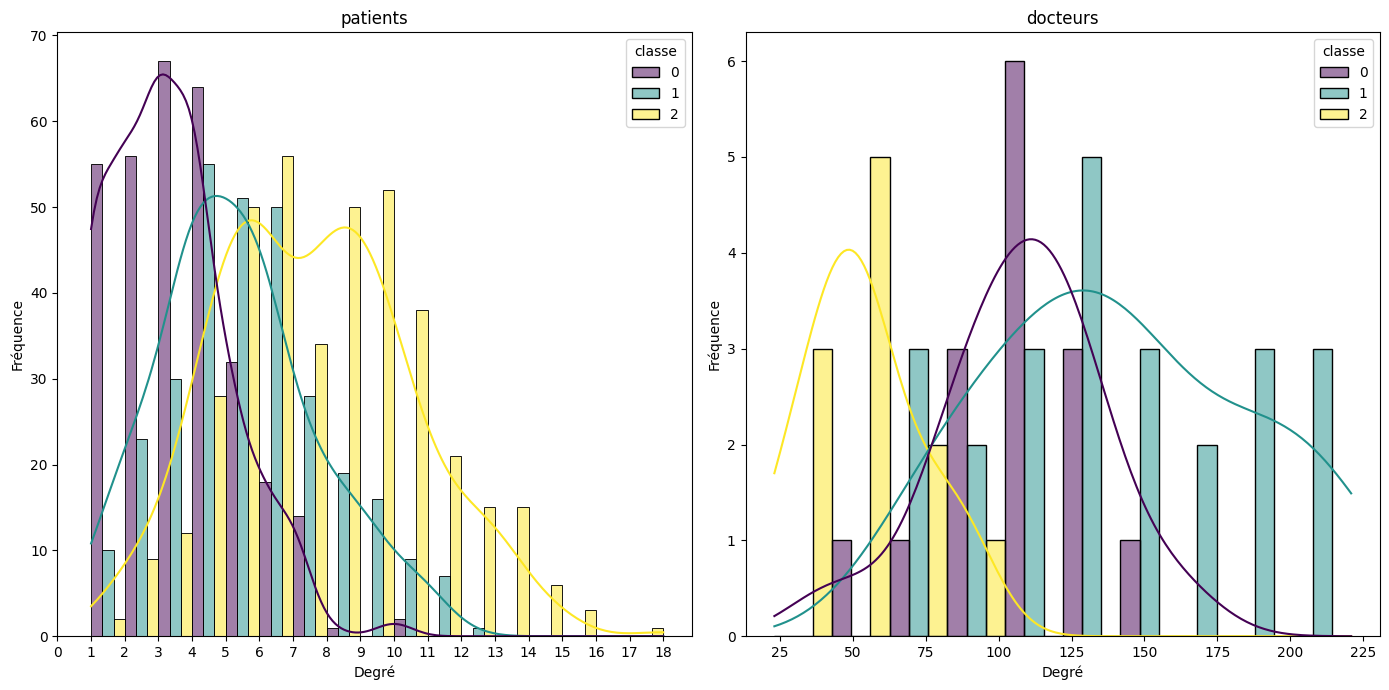

In [5]:
plot_functions.plot_hist_degree(graph_object, hue_class = True, save = False)

#### EF et animations

In [16]:
# Training
estimates = get_estimations(graph_object.df, nb_epochs=150, show_print=0, dim_embedding=2)

# Recuperation des poids au niveau des embeddings
ef_patient_hat = estimates[1][0]
ef_doctor_hat = estimates[1][1]

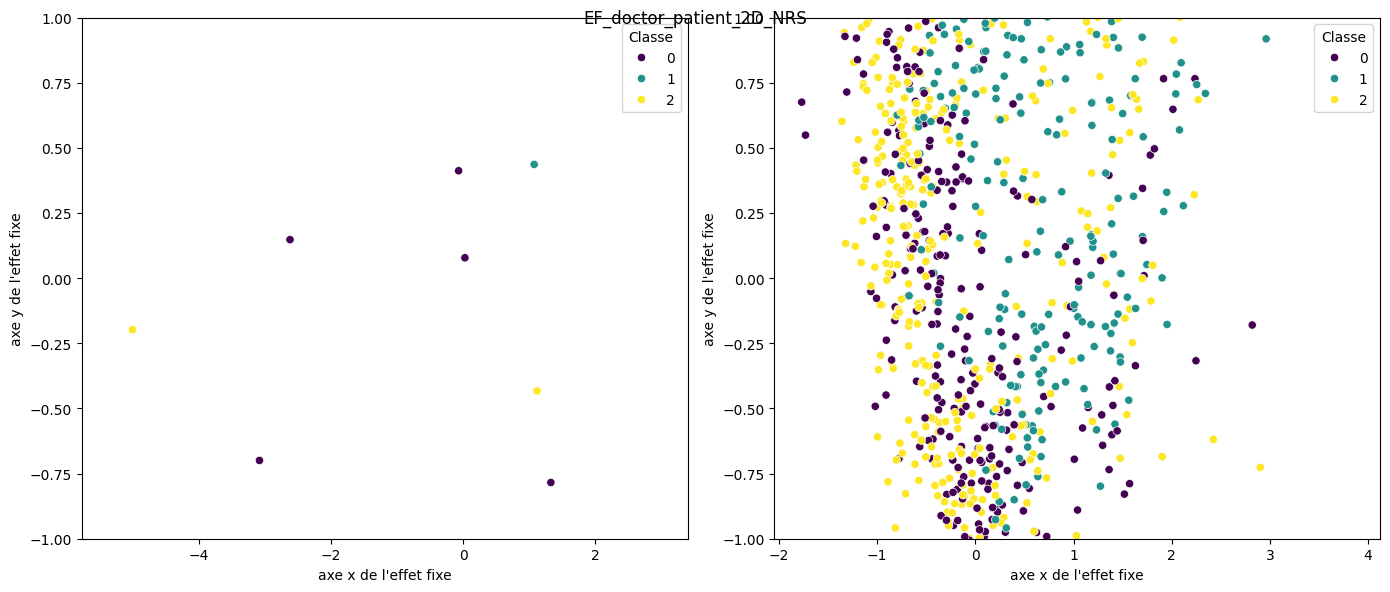

In [14]:
plot_functions.plot_ef_2D(graph_object, ef_patient = ef_patient_hat, ef_doctor = ef_doctor_hat, save = False, title = "EF_doctor_patient_2D_NRS")

Nos visualisations ne sont pas très satisfaisantes. Certains clusters peinent à se distinguer

Save done
Temps d'exécution : 525 secondes


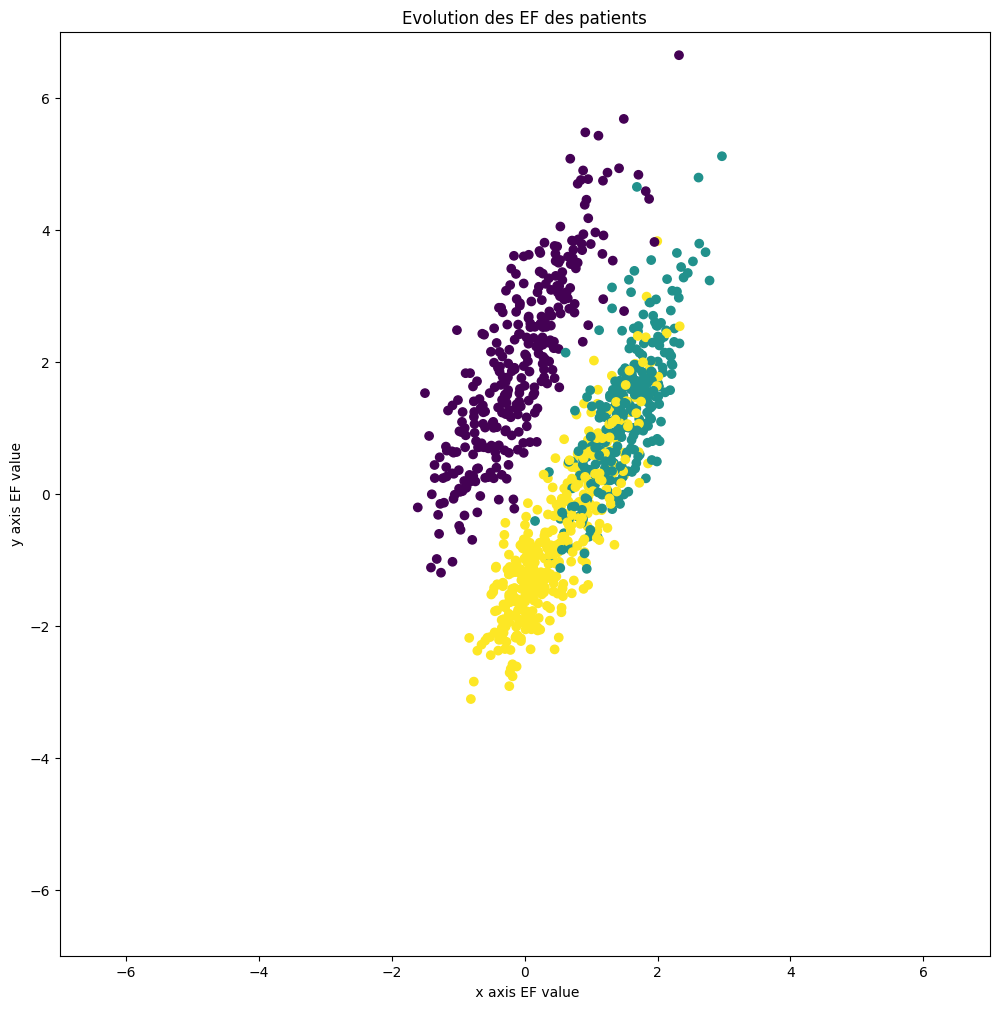

In [78]:
# Temps d'exécution : 525 secondes
animation.animation_embedding_2D(graph_object, nb_epochs=150)

Save done
Temps d'exécution : 513 secondes


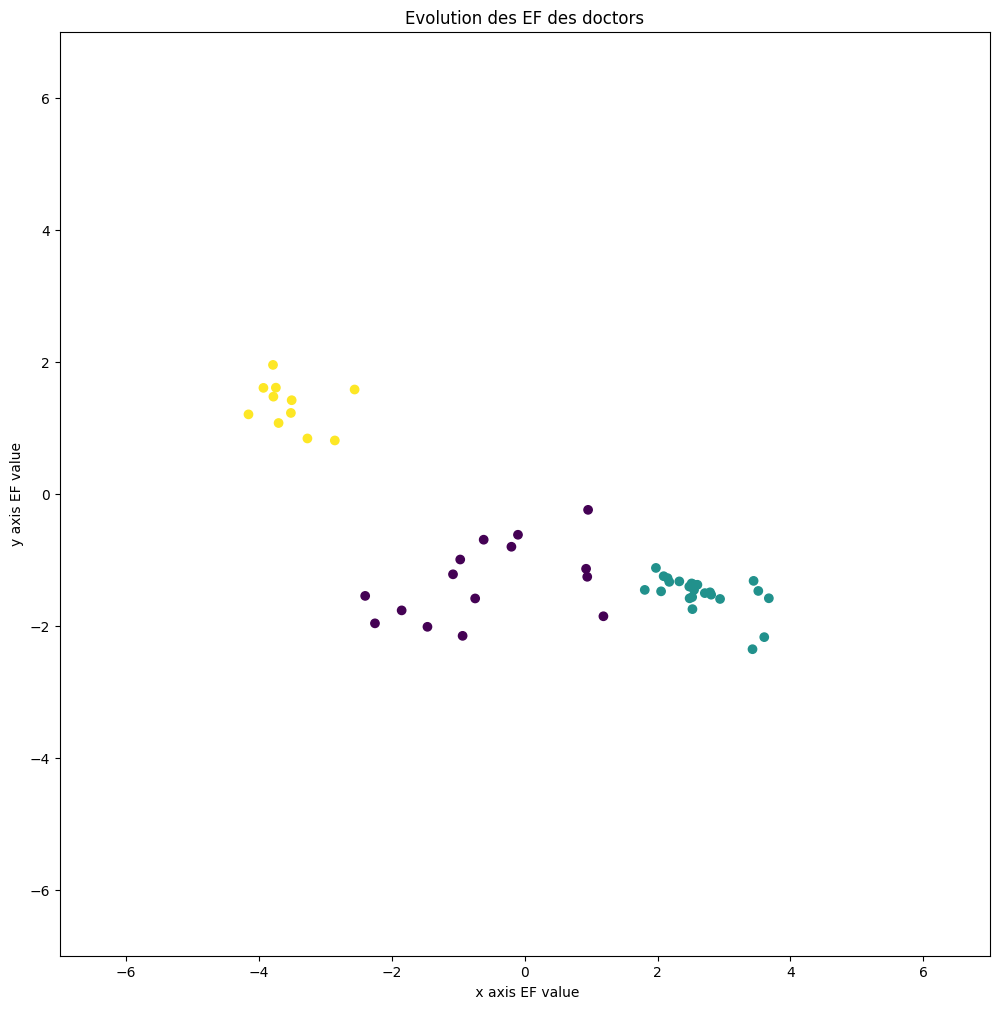

In [79]:
animation.animation_embedding_2D(graph_object, nb_epochs=150, who="doctor")

### Clustering, AMI et visualisation

In [18]:
# Initialiser le modèle KMeans avec 3 clusters
kmeans_d = KMeans(n_clusters=3, random_state=2)
# Ajuster le modèle sur les données
kmeans_d.fit(ef_doctor_hat)
# On retire les labels attribués
cluster_doctor_hat = kmeans_d.labels_

# Initialiser le modèle KMeans avec 3 clusters
kmeans_p = KMeans(n_clusters=3, random_state=3)
# Ajuster le modèle sur les données
kmeans_p.fit(ef_patient_hat)
# On retire les labels attribués
cluster_patient_hat = kmeans_p.labels_

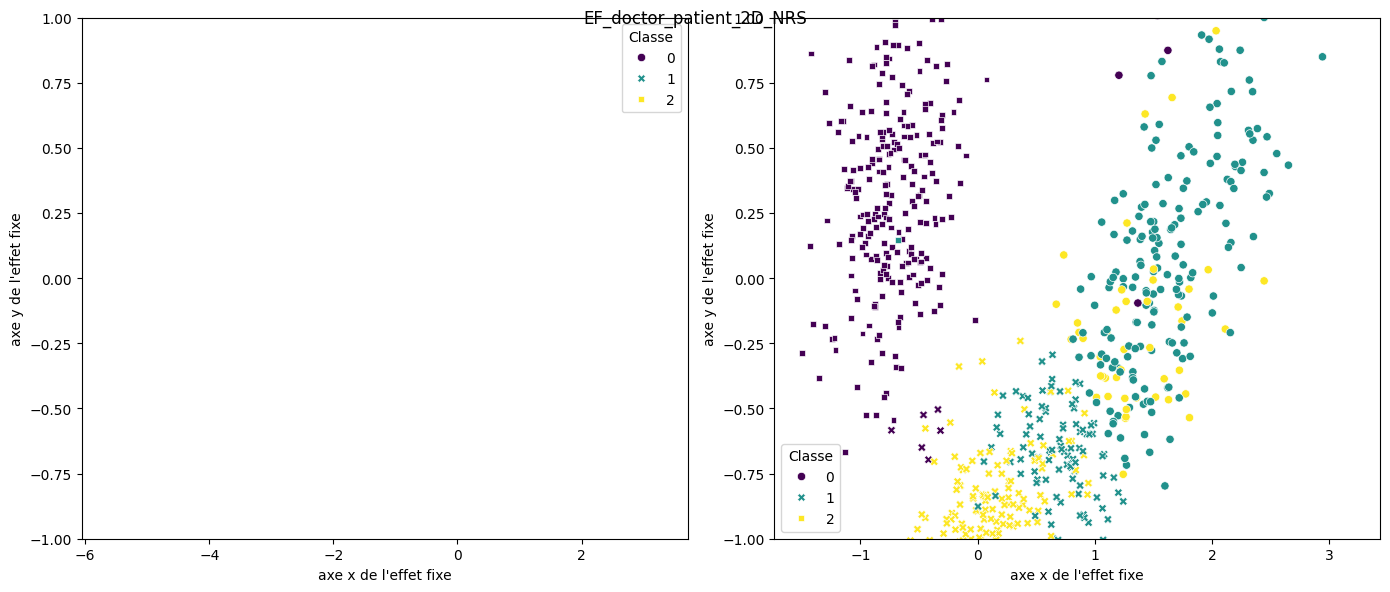

In [20]:
plot_functions.plot_ef_2D(graph_object, ef_patient = ef_patient_hat, ef_doctor = ef_doctor_hat, save = False, style_d = cluster_doctor_hat, style_p = cluster_patient_hat, title = "EF_doctor_patient_2D_NRS")

In [83]:
metric_doctor_hat =  metrics.adjusted_rand_score(graph_object.psi_class, cluster_doctor_hat)
print(f"AMI du clustering sur l'embedding estimé des docteurs: {metric_doctor_hat}")
metric_patient_hat =   metrics.adjusted_rand_score(graph_object.alpha_class, cluster_patient_hat)
print(f"AMI du clustering sur l'embedding estimé des patients: {metric_patient_hat}")

AMI du clustering sur l'embedding estimé des docteurs: 0.9326862732055216
AMI du clustering sur l'embedding estimé des patients: 0.6192218514089336


### Robustesse

In [ ]:
simulation.robustesse_all(100, 0.8, graph_object, nb_epochs = 50, dim_embedding = 2,  algorithm = "MF")

simulation 1: done
simulation 2: done


## High dimensional case (méthode de la sphère)

Ici, nous allons simuler d'une autre façon les effets fixes. Voir rapport pour plus de précision.

### Formation du graphe

In [6]:
#Exemple de foramtion de graphe avec des EF 5D (gaussian sphere)
identity_matrices = np.array([np.eye(5) for _ in range(6)])


graph_object= GraphFormation(
                    n_patients=1000,
                     n_doctors=50,
                     max_number_connections=50,
                    beta_distance_graph = -25,
                    psi_law_stds= identity_matrices,
                    alpha_law_stds = identity_matrices,
                    std_multiplier_p=0.3,
                    std_multiplier_d=0.5,
                    nb_latent_factors=5,
                    gaussian_sphere = True,
                    radius = 4,
                    seed=12)
graph_object.do_the_graph()
print(f"density of the graph: {graph_object.density*100:.2f}%")

density of the graph: 10.74%


### Etude Préléminaires

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Mean Squared Error sur l'échantillon de test : 0.39157415744960083
Precision: 0.65
Recall: 0.58
F1-score: 0.62
ESTIMATION BETA: X p [0.19668318]; X d [-0.31904718]; D_p [0.6844724]; D_d [1.0229068]; distance [-9.041651]
ERROR ESTIMATION BETA: X p [-0.00331682]; X d [-0.5190472]; D_p [-0.31552762]; D_d [0.02290678]; distance [15.958349]


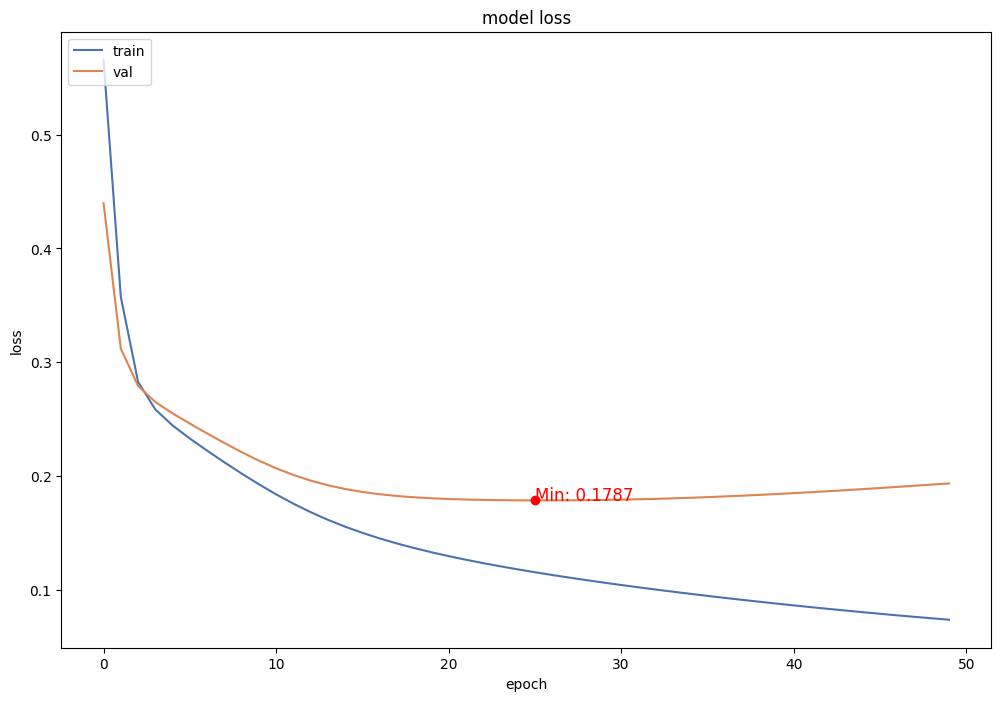

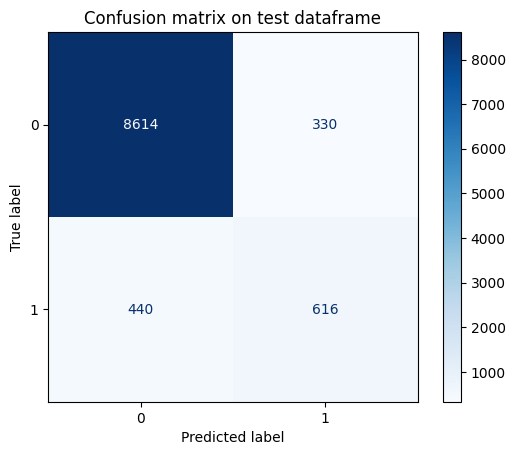

Temps d'exécution : 78 secondes


In [195]:
MF_NRS.prediction_score(graph_object, dim_embedding=5, nb_epochs=50)

density of the graph: 15.29%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Mean Squared Error sur l'échantillon de test : 0.5078195229980916
Precision: 0.67
Recall: 0.72
F1-score: 0.70
ESTIMATION BETA: X p [0.289519]; X d [-0.2668246]; D_p [1.2677107]; D_d [0.97631437]; distance [-13.601416]
ERROR ESTIMATION BETA: X p [0.08951901]; X d [-0.4668246]; D_p [0.2677107]; D_d [-0.02368563]; distance [6.3985844]


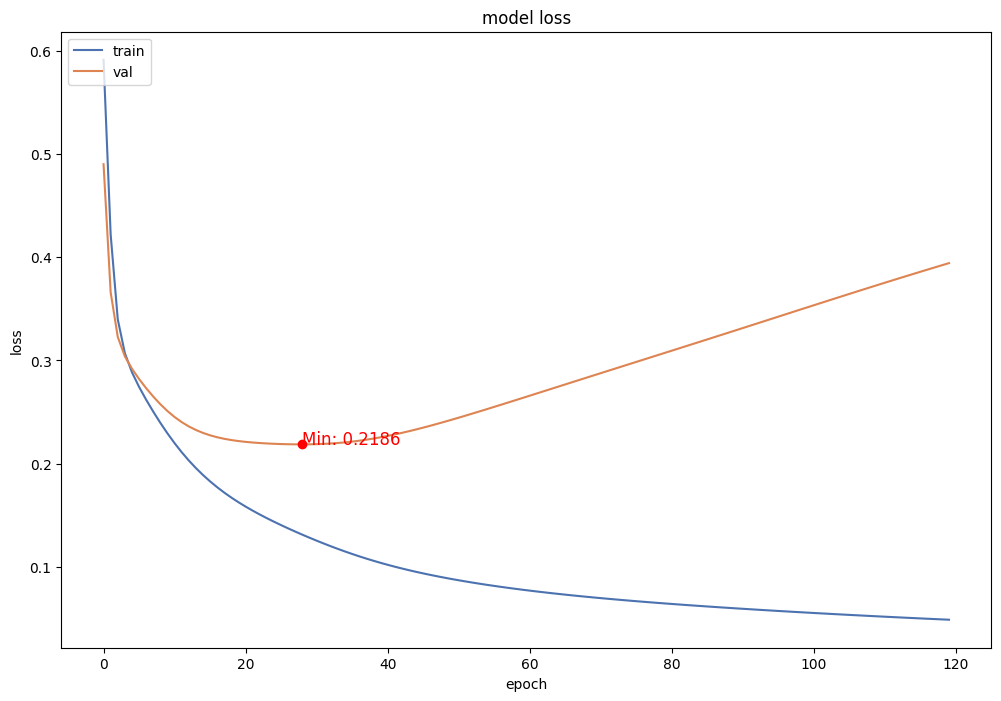

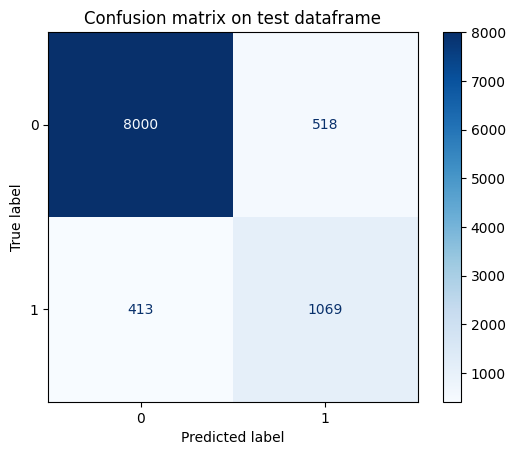

Temps d'exécution : 177 secondes
density of the graph: 22.34%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Mean Squared Error sur l'échantillon de test : 0.5709572506365888
Precision: 0.75
Recall: 0.77
F1-score: 0.76
ESTIMATION BETA: X p [0.27877316]; X d [-0.14559126]; D_p [1.4093819]; D_d [1.2860299]; distance [-12.804498]
ERROR ESTIMATION BETA: X p [0.07877316]; X d [-0.34559125]; D_p [0.40938187]; D_d [0.28602993]; distance [2.1955023]


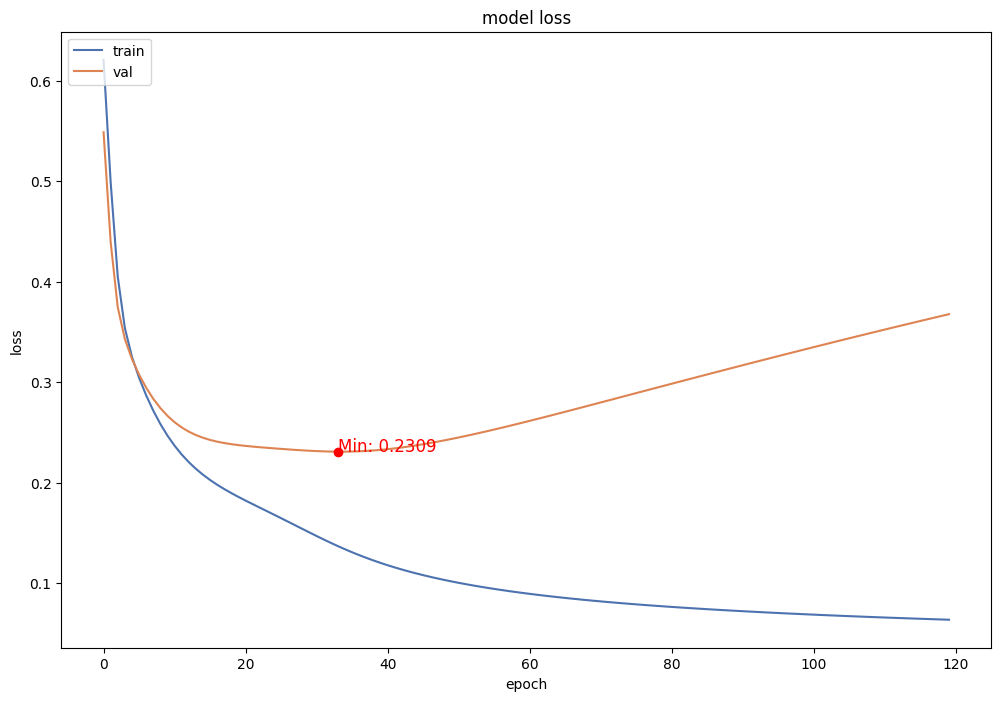

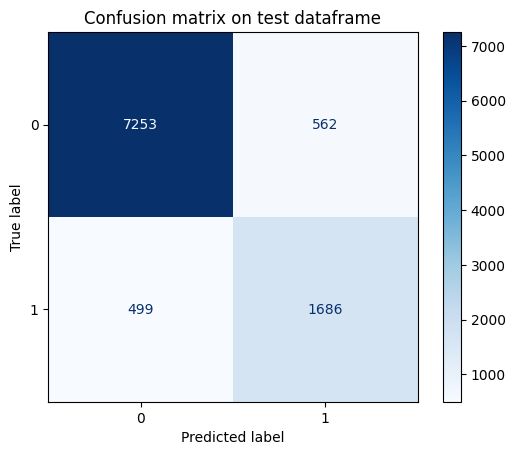

Temps d'exécution : 179 secondes
density of the graph: 28.37%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Mean Squared Error sur l'échantillon de test : 0.6217561402696178
Precision: 0.78
Recall: 0.81
F1-score: 0.80
ESTIMATION BETA: X p [0.19223285]; X d [-0.11442086]; D_p [1.47518]; D_d [1.5004365]; distance [-11.522704]
ERROR ESTIMATION BETA: X p [-0.00776716]; X d [-0.31442088]; D_p [0.47518003]; D_d [0.50043654]; distance [0.47729588]


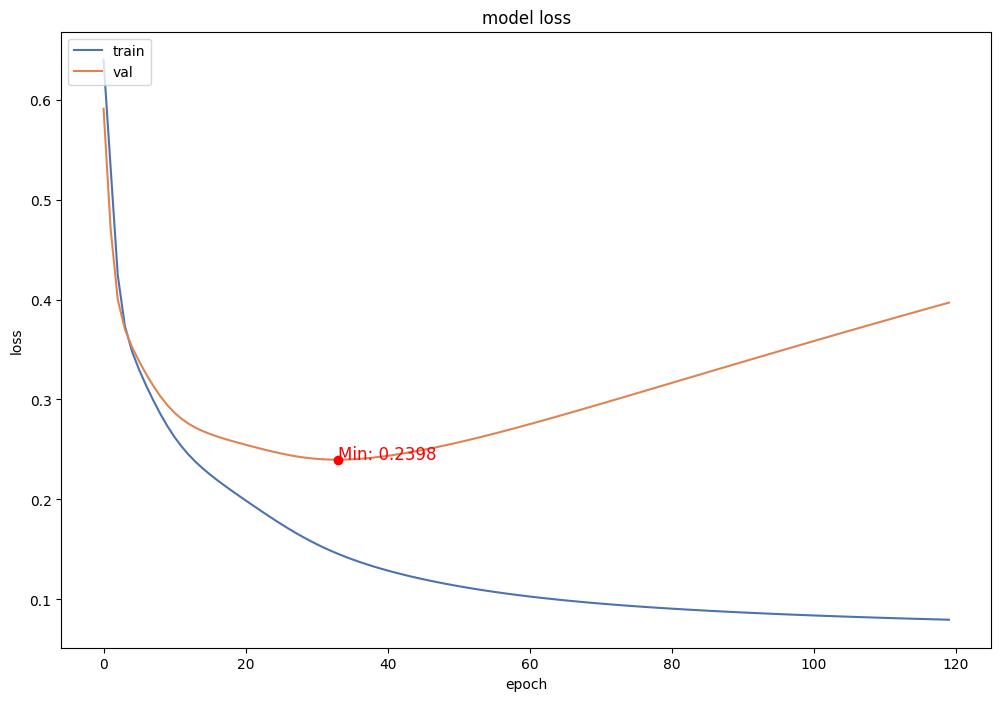

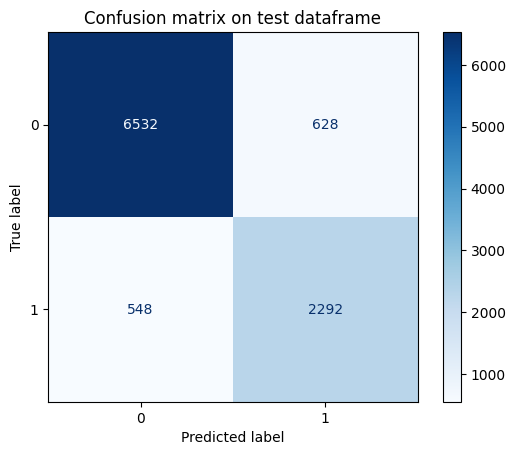

Temps d'exécution : 171 secondes
density of the graph: 33.04%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Mean Squared Error sur l'échantillon de test : 0.583006303720116
Precision: 0.83
Recall: 0.82
F1-score: 0.83
ESTIMATION BETA: X p [0.18646395]; X d [0.30385005]; D_p [1.4784026]; D_d [1.6281426]; distance [-10.684035]
ERROR ESTIMATION BETA: X p [-0.01353605]; X d [0.10385005]; D_p [0.4784026]; D_d [0.6281426]; distance [-0.6840353]


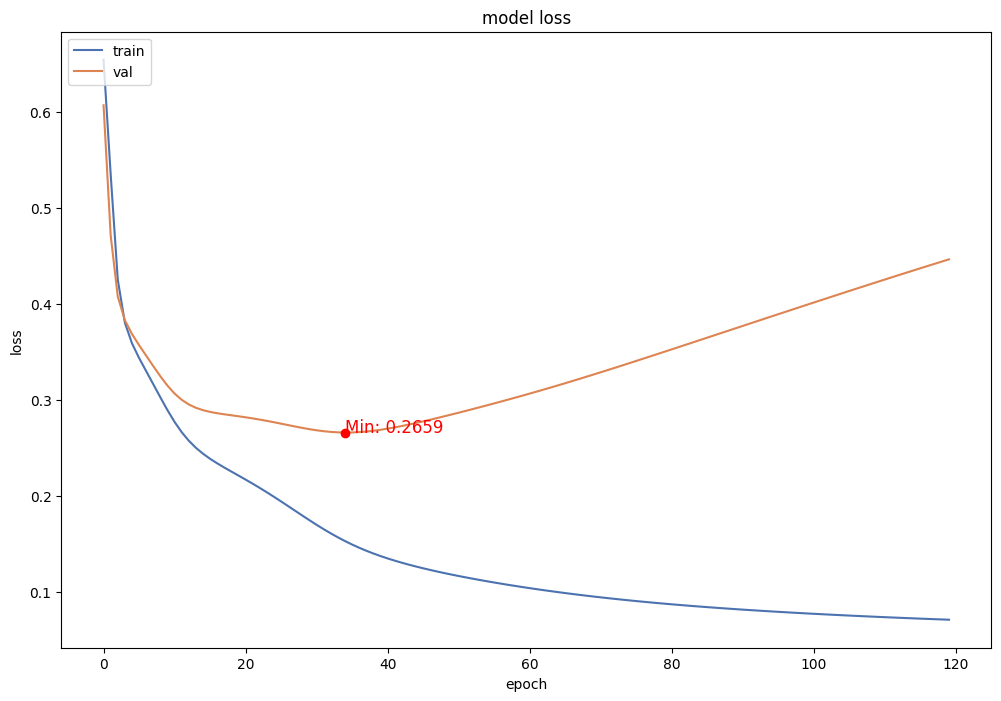

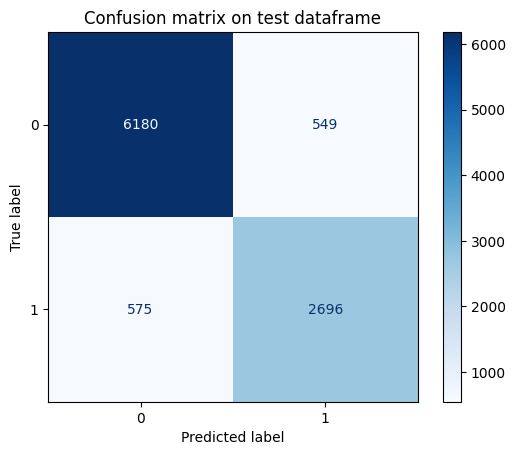

Temps d'exécution : 165 secondes
density of the graph: 40.05%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Mean Squared Error sur l'échantillon de test : 0.5331476024078879
Precision: 0.87
Recall: 0.88
F1-score: 0.88
ESTIMATION BETA: X p [0.1882324]; X d [0.14856292]; D_p [1.3566421]; D_d [1.6915735]; distance [-7.932688]
ERROR ESTIMATION BETA: X p [-0.0117676]; X d [-0.05143708]; D_p [0.35664213]; D_d [0.6915735]; distance [-0.93268824]


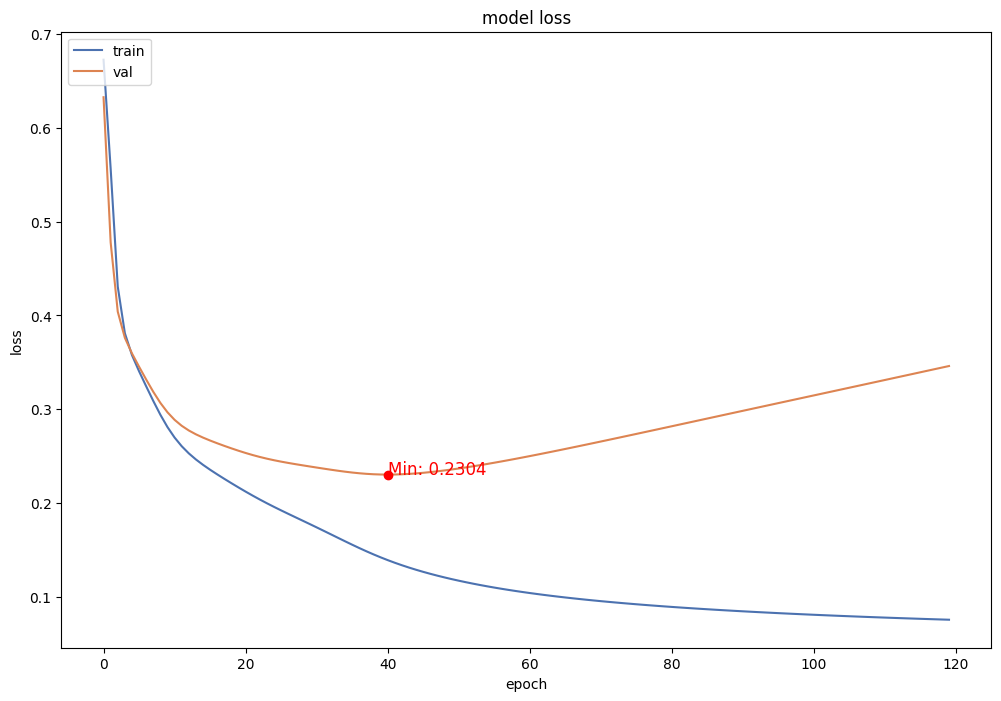

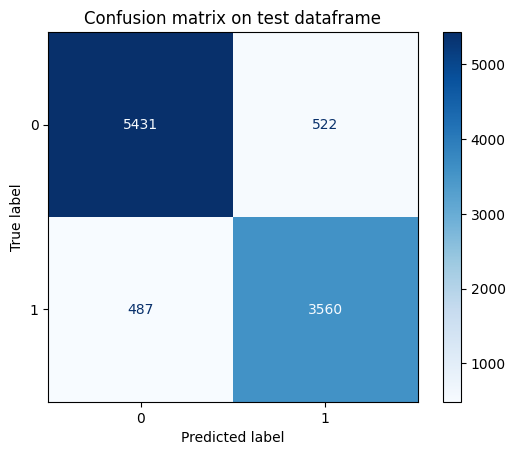

Temps d'exécution : 170 secondes
density of the graph: 44.95%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Mean Squared Error sur l'échantillon de test : 0.5563699076334143
Precision: 0.88
Recall: 0.89
F1-score: 0.89
ESTIMATION BETA: X p [0.31824395]; X d [0.19715397]; D_p [1.3673922]; D_d [1.5416858]; distance [-6.0056067]
ERROR ESTIMATION BETA: X p [0.11824395]; X d [-0.00284603]; D_p [0.36739218]; D_d [0.5416858]; distance [-1.0056067]


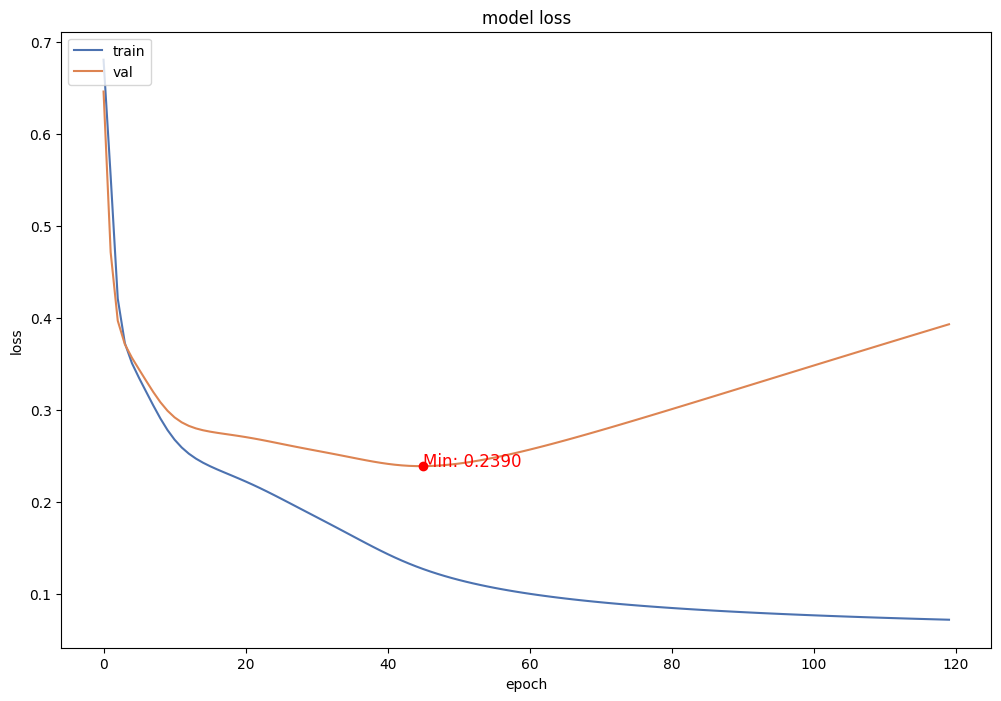

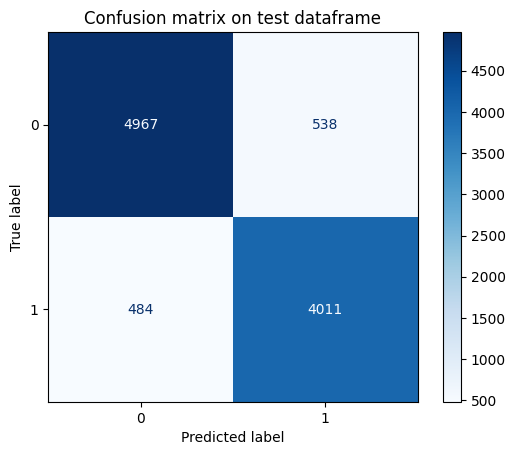

Temps d'exécution : 174 secondes
density of the graph: 49.68%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Mean Squared Error sur l'échantillon de test : 0.536548448006647
Precision: 0.90
Recall: 0.90
F1-score: 0.90
ESTIMATION BETA: X p [0.23951542]; X d [-0.14322789]; D_p [1.5583384]; D_d [1.0753928]; distance [-3.7749112]
ERROR ESTIMATION BETA: X p [0.03951542]; X d [-0.3432279]; D_p [0.5583384]; D_d [0.07539284]; distance [-0.77491117]


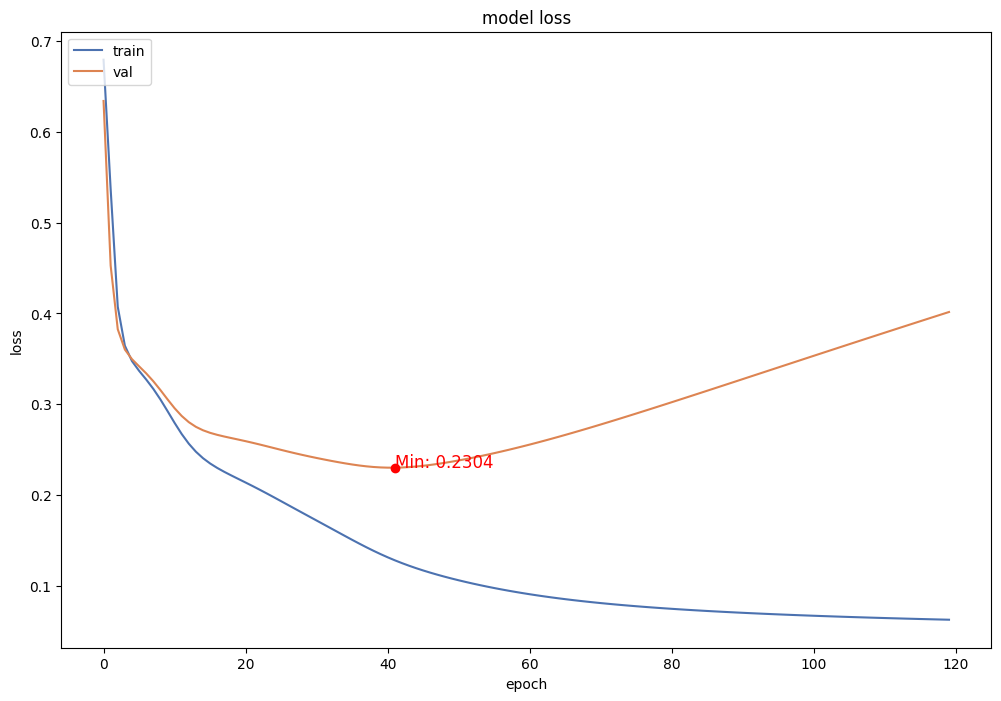

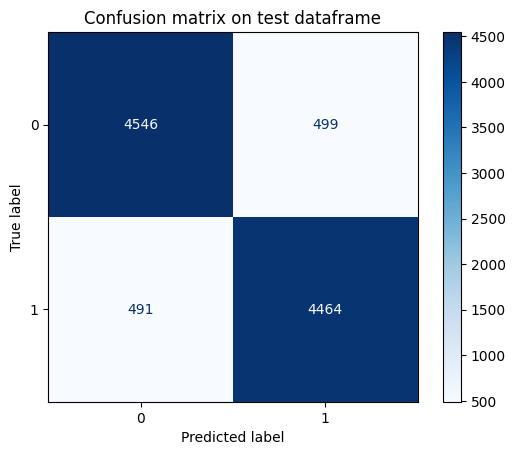

Temps d'exécution : 172 secondes
density of the graph: 52.03%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Mean Squared Error sur l'échantillon de test : 0.5260810048433657
Precision: 0.90
Recall: 0.91
F1-score: 0.91
ESTIMATION BETA: X p [0.26885003]; X d [0.04371654]; D_p [1.2956609]; D_d [1.0804398]; distance [-2.1745353]
ERROR ESTIMATION BETA: X p [0.06885003]; X d [-0.15628347]; D_p [0.29566085]; D_d [0.08043981]; distance [-0.17453527]


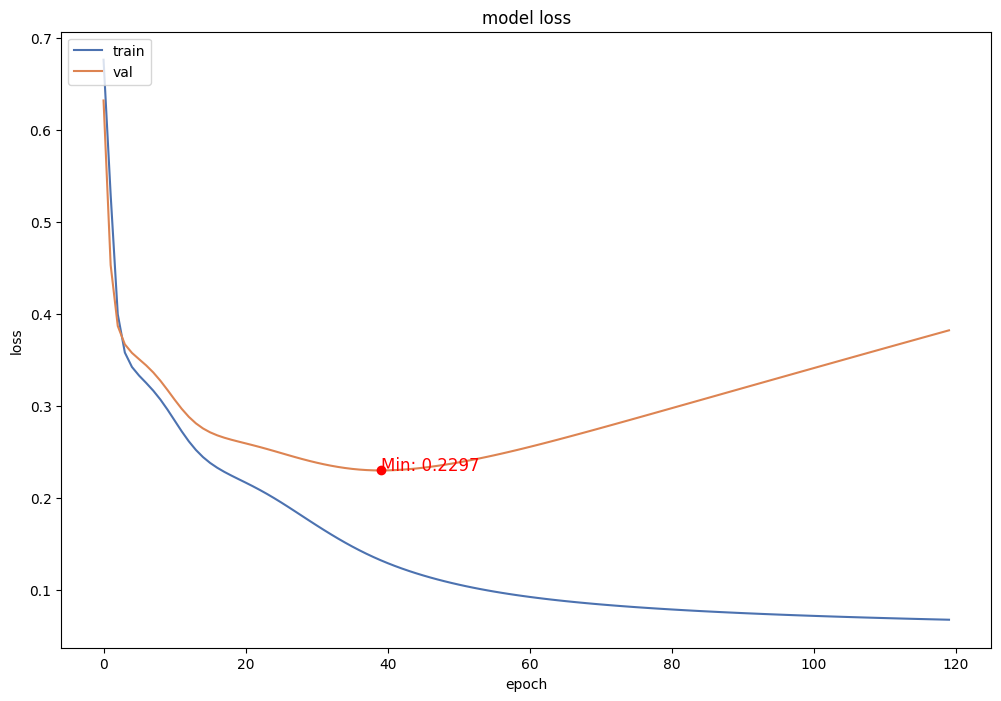

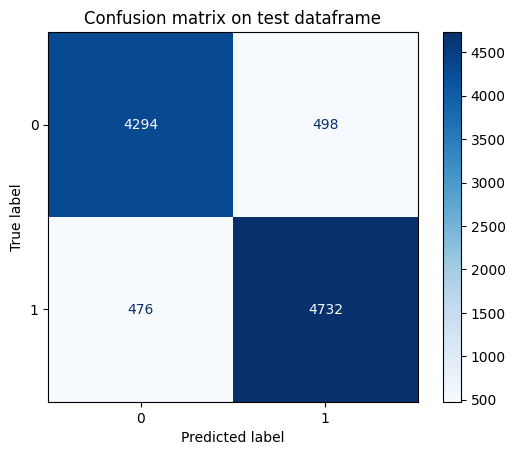

Temps d'exécution : 175 secondes
Temps d'exécution : 1389 secondes


In [189]:
MF_NRS.loss_vs_density(sim_beta_distance_array = [-20,-15, -12, -10,-7,-5, -3, -2,],
                       nb_epochs = 120,  
                       valid_split=0.1, 
                       gaussian_sphere=True, 
                       std_multiplier_p=0.3, 
                       std_multiplier_d=1,
                       nb_latent_factors=5,
                       radius=4, 
                       seed = 12)

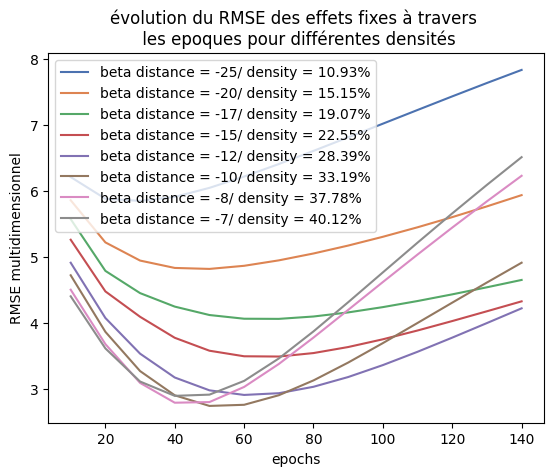

Temps d'exécution : 2144 secondes


In [193]:
# Temps d'exécution : 2344 secondes
density_ami_rmse_simulation.plot_rmse_epochs_multiD(n=14,
                                                    save=True,
                                                    sim_beta_distance_array = [-25,-20, -17, -15,-12,-10, -8, -7,],
                                                    epochs_step = 10, 
                                                    gaussian_sphere=True,
                                                    std_multiplier_p=0.3, 
                                                    std_multiplier_d=1, 
                                                    nb_latent_factors=5, 
                                                    radius=4,
                                                   seed = 12)

### Visualisation

#### Histogrammmes des degrés

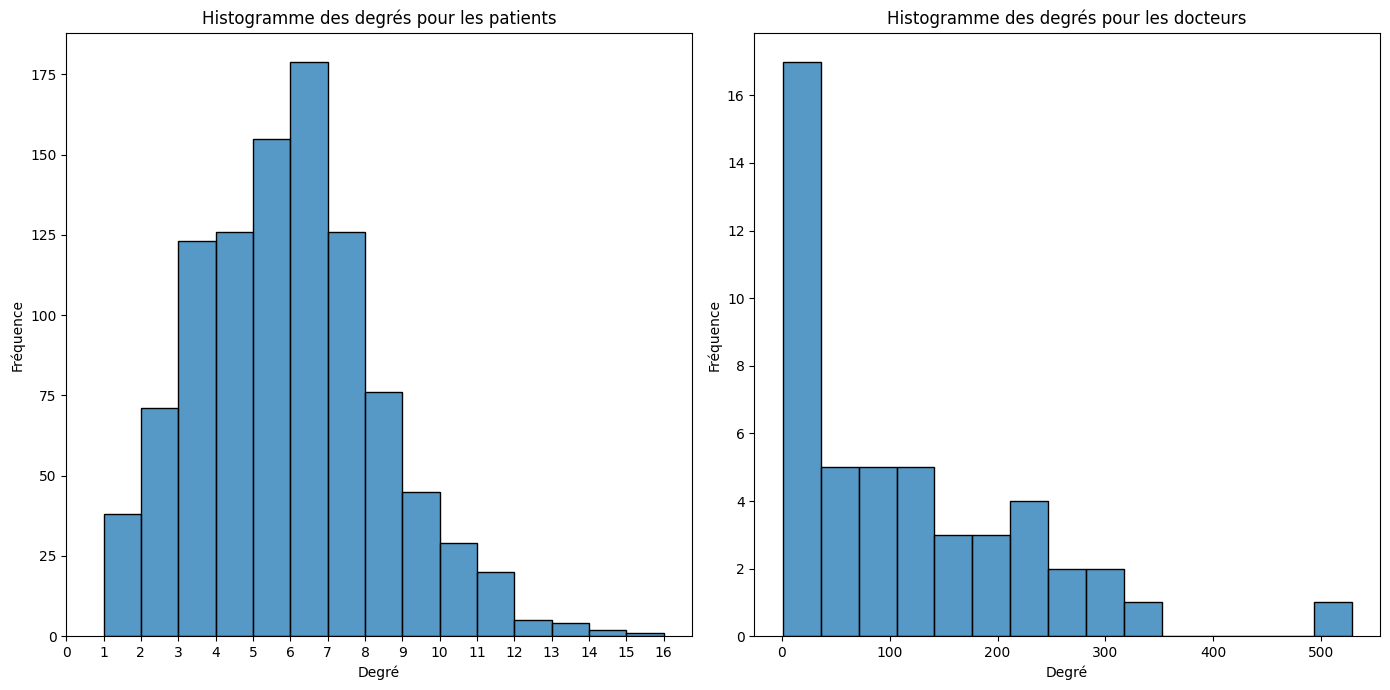

In [21]:
plot_functions.plot_hist_degree(graph_object, hue_class = False, save = False)

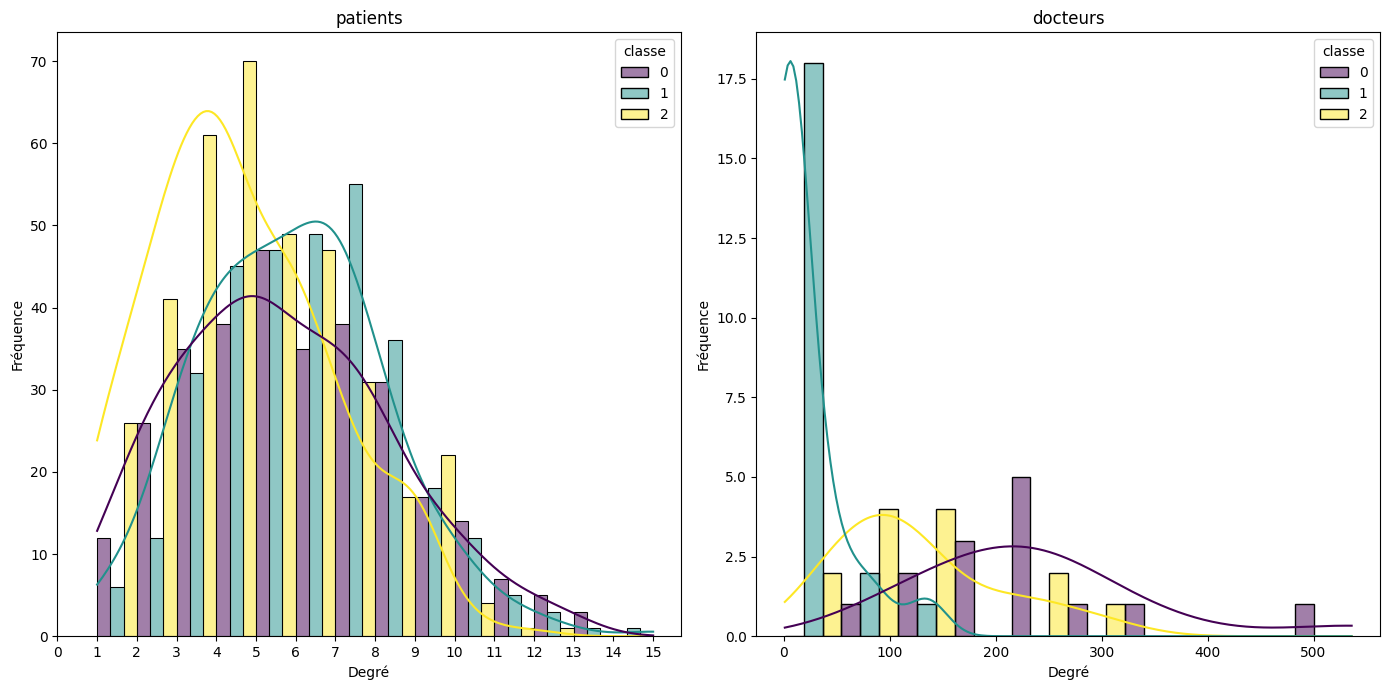

In [7]:
plot_functions.plot_hist_degree(graph_object, hue_class = True, save = True)

#### Sur le vrai embedding

In [31]:
#RD = TSNE(n_components=2)
RD = PCA(n_components=2)
ef_patient_2D, ef_doctor_2D = RD.fit_transform(graph_object.alpha_graph), RD.fit_transform(graph_object.psi_graph)

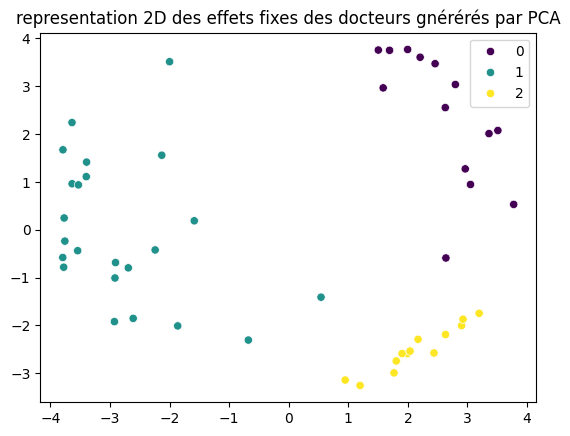

In [32]:
#Visualisation des EF docteur
sns.set_palette("deep") 

# La couleur représente le degré, c'est-à-dire le nombre de lien qu'a le docteur
sns.scatterplot( x= ef_doctor_2D[:,0], y=ef_doctor_2D[:,1], hue=graph_object.psi_class, palette='viridis')
#plt.savefig("EF_star_5D_PCA_doctor")
plt.title("representation 2D des effets fixes des docteurs gnérérés par PCA")
plt.show()

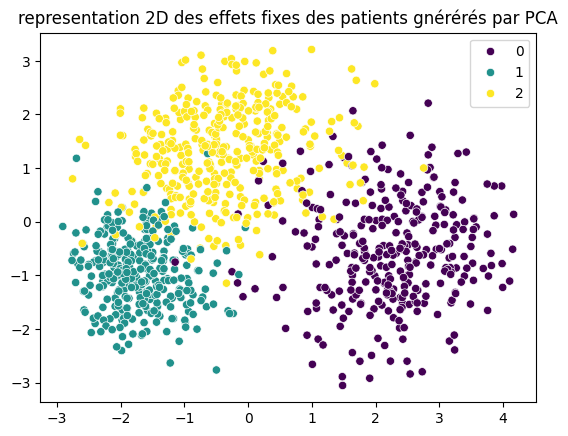

In [33]:
#Visualisation des EF patients
sns.set_palette("deep") 
# La couleur représente le degré, c'est-à-dire le nombre de lien qu'a le docteur
sns.scatterplot(x= ef_patient_2D[:,0], y=  ef_patient_2D[:,1], hue=graph_object.alpha_class, palette='viridis')
#plt.savefig("EF_star_5D_PCA_patient")
plt.title("representation 2D des effets fixes des patients gnérérés par PCA")
plt.show()

Les clusters dans la génération sont bien identifiables.

#### Sur l'embedding estimé

In [56]:
# Training
estimates = get_estimations(graph_object.df, nb_epochs=50, show_print=0, dim_embedding=5)

# Recuperation des poids au niveau des embeddings
ef_patient_hat = estimates[1][0]
ef_doctor_hat = estimates[1][1]

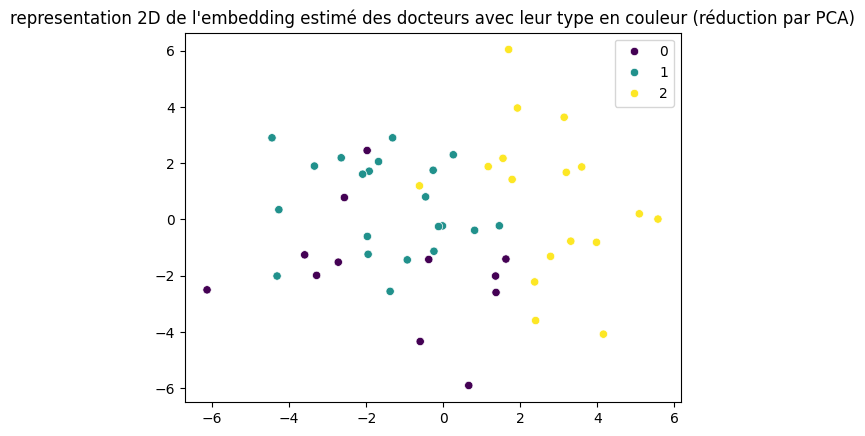

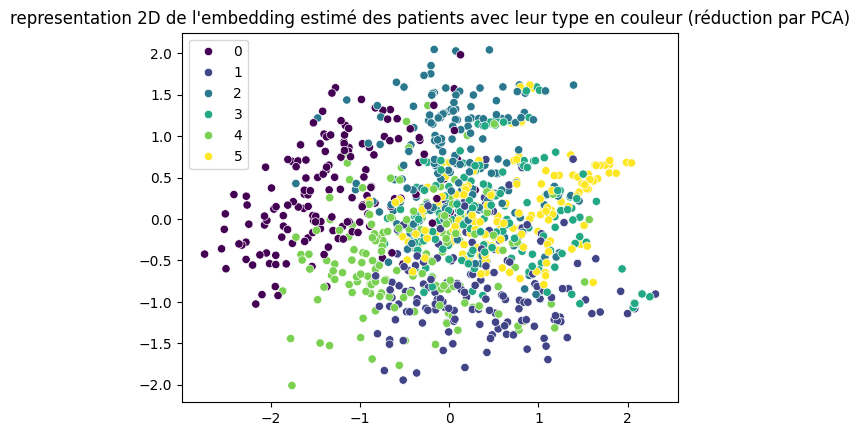

Temps d'exécution : 0 secondes


In [57]:
# Temps d'exécution : 0 secondes
plot_functions.plot_ef_RD(graph_object = graph_object, ef_patient = ef_patient_hat, ef_doctor= ef_doctor_hat, RD_method = "PCA" , save = False)

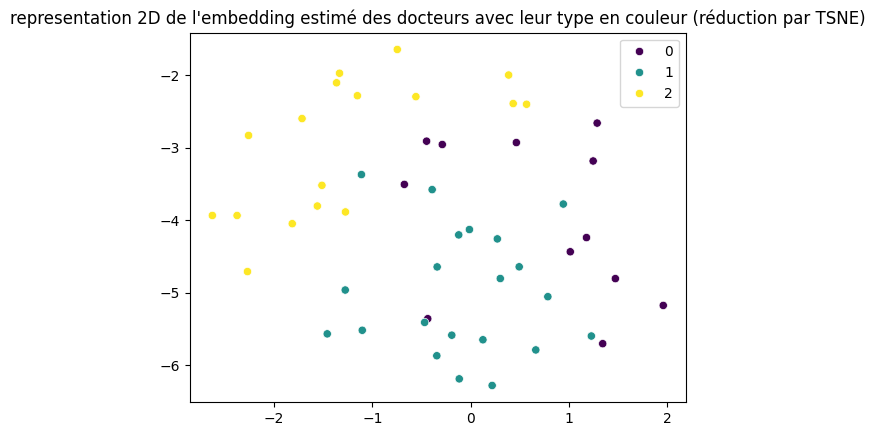

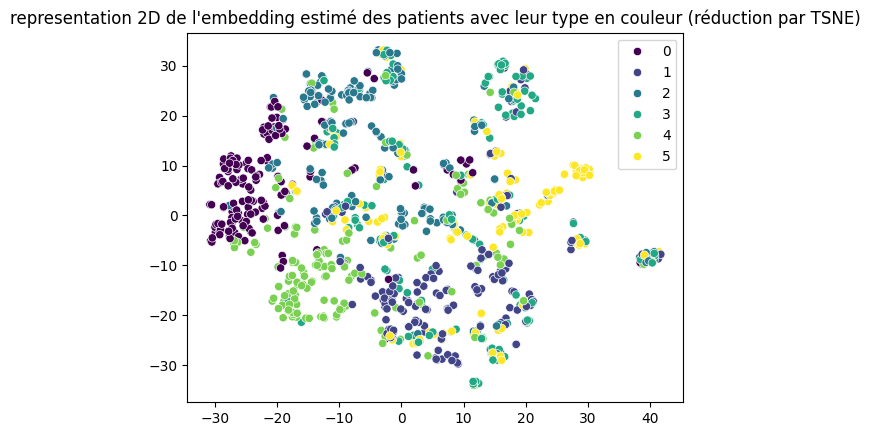

Temps d'exécution : 5 secondes


In [58]:
#Temps d'exécution : 5 secondes
plot_functions.plot_ef_RD(graph_object = graph_object, ef_patient = ef_patient_hat, ef_doctor= ef_doctor_hat, RD_method = "TSNE", save= False)

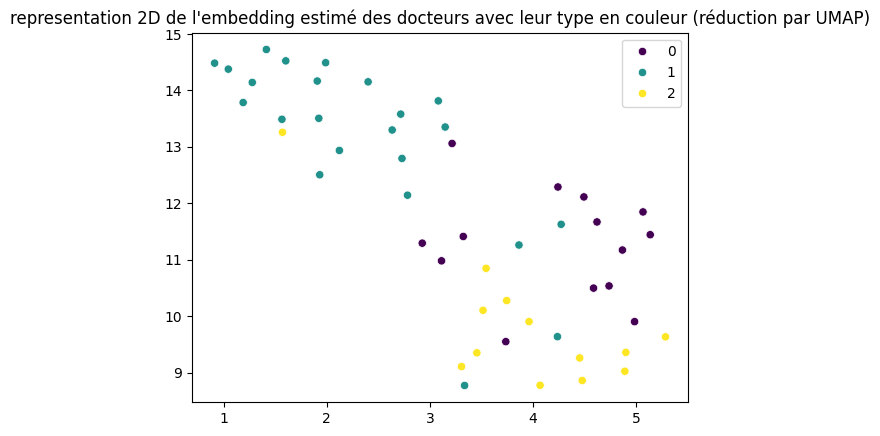

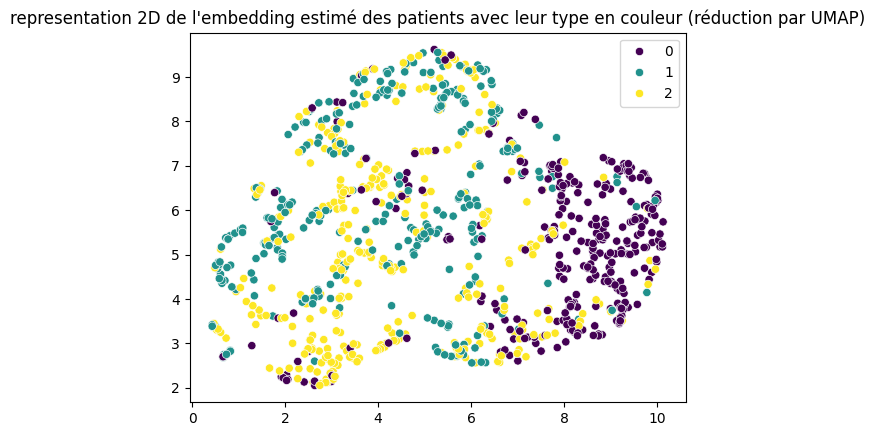

Temps d'exécution : 101 secondes


In [245]:
# Temps d'exécution : 101 secondes
plot_functions.plot_ef_RD(graph_object = graph_object, ef_patient = ef_patient_hat, ef_doctor= ef_doctor_hat, RD_method = "UMAP")

#### Animation

Save done


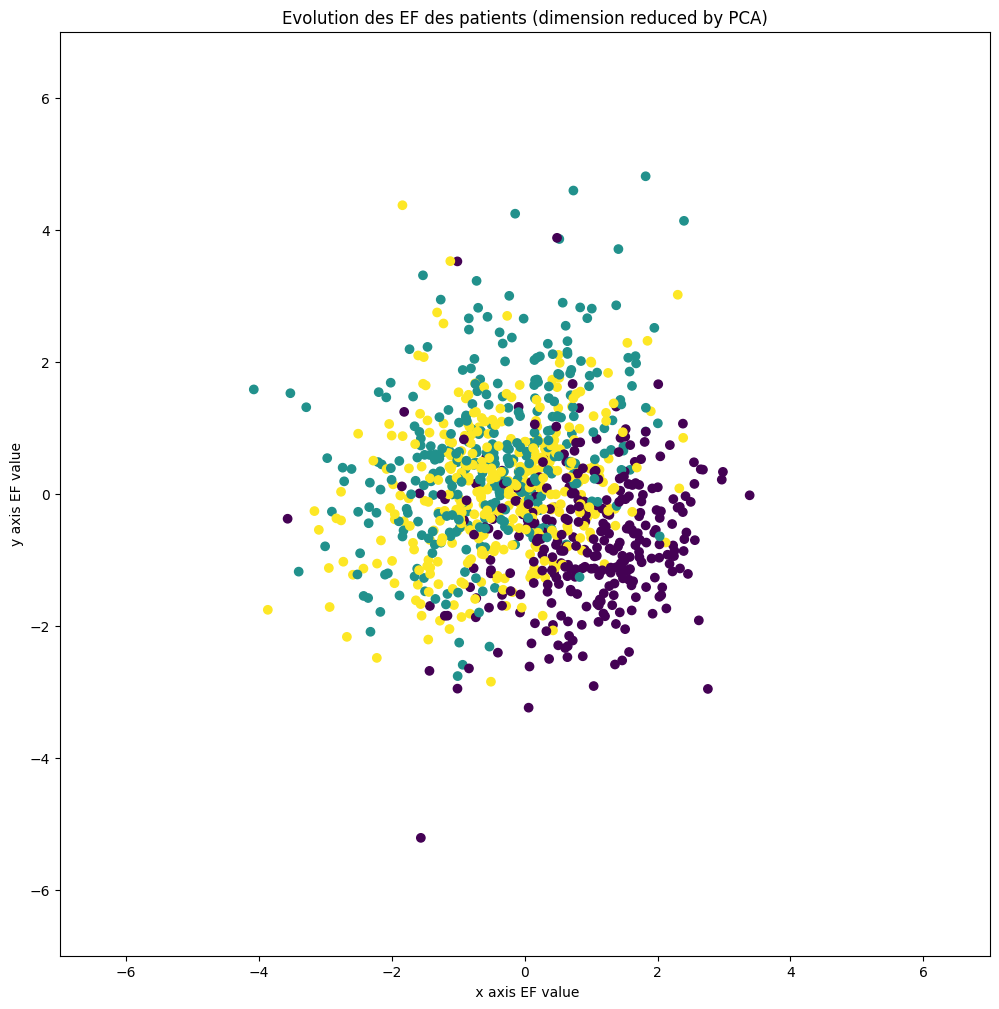

In [187]:
animation.animation_embedding_XD(graph_object, who="patient", nb_epochs=150)

Save done


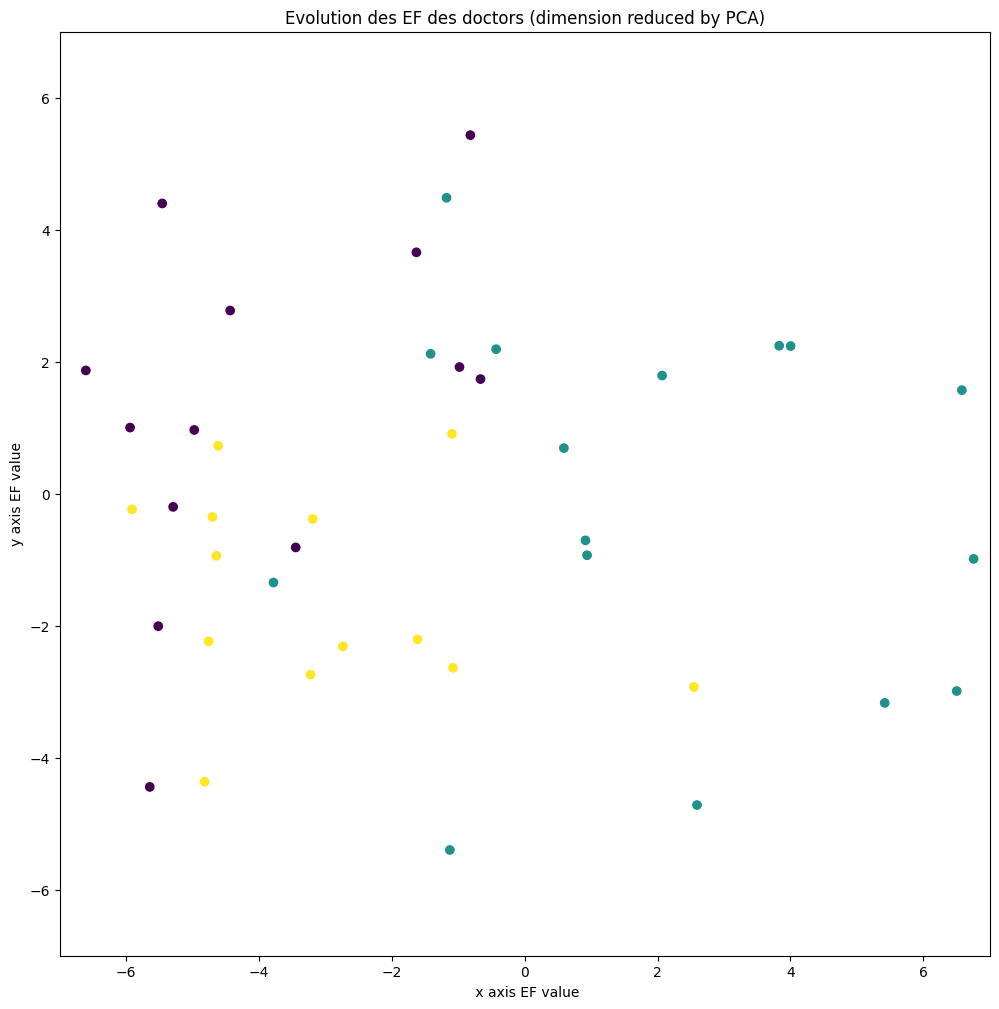

In [188]:
animation.animation_embedding_XD(graph_object, who="doctor", nb_epochs=150)

### Clustering, AMI et visualisation

#### Clustering sur l'embedding 5d estimé

Commençons par lancer le K means sur les ef estimés:

In [61]:
# Initialiser le modèle KMeans avec 3 clusters
kmeans_d = KMeans(n_clusters=3, random_state=2)
# Ajuster le modèle sur les données
kmeans_d.fit(ef_doctor_hat)
# On retire les labels attribués
cluster_doctor_hat = kmeans_d.labels_

# Initialiser le modèle KMeans avec 3 clusters
kmeans_p = KMeans(n_clusters=5, random_state=3)
# Ajuster le modèle sur les données
kmeans_p.fit(ef_patient_hat)
# On retire les labels attribués
cluster_patient_hat = kmeans_p.labels_

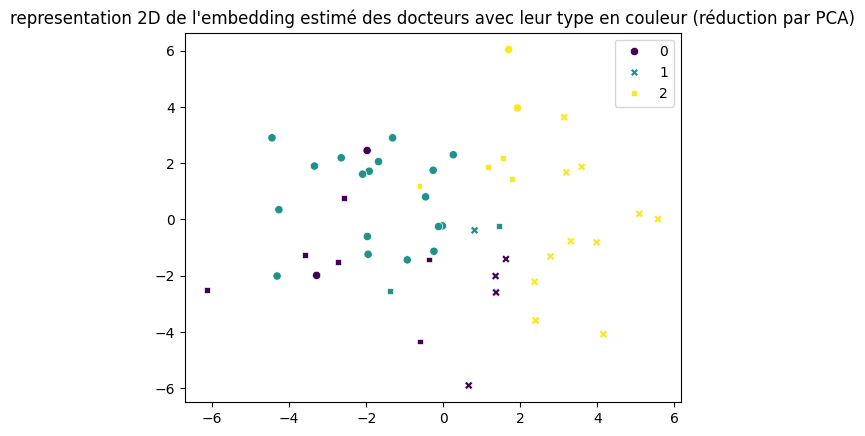

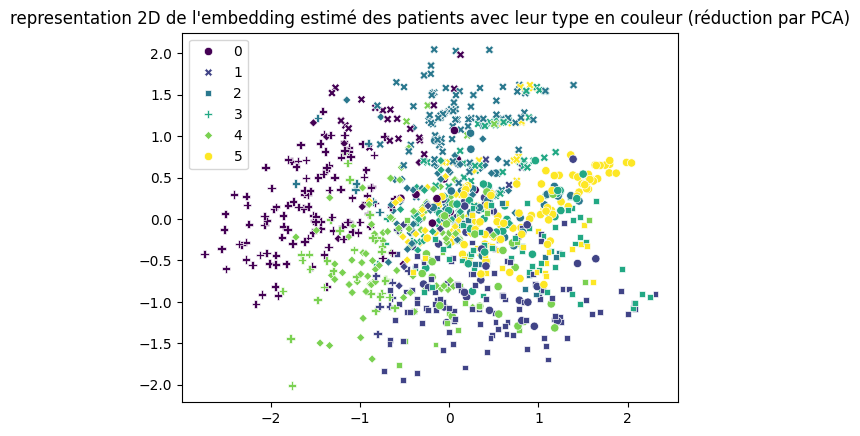

Temps d'exécution : 0 secondes


In [64]:
# Visualisation avec PCA des clusters estimés
plot_functions.plot_ef_RD(graph_object = graph_object, 
                   ef_patient = ef_patient_hat, 
                   ef_doctor= ef_doctor_hat,
                   RD_method = "PCA" ,
                   save = False,
                   label_doctor = cluster_doctor_hat,
                   label_patient = cluster_patient_hat) 

In [63]:
metric_doctor_hat =  metrics.adjusted_rand_score(graph_object.psi_class, cluster_doctor_hat)
print(f"AMI du clustering sur l'embedding estimé des docteurs: {metric_doctor_hat}")
metric_patient_hat =   metrics.adjusted_rand_score(graph_object.alpha_class, cluster_patient_hat)
print(f"AMI du clustering sur l'embedding estimé des patients: {metric_patient_hat}")

AMI du clustering sur l'embedding estimé des docteurs: 0.35643092822476585
AMI du clustering sur l'embedding estimé des patients: 0.19629902373104727


#### Clustering sur l'embedding réduit par réduction de dimension

In [19]:
#RD  = PCA(n_components=2)
RD =  TSNE(n_components=2)
ef_patient_RD, ef_doctor_RD = RD.fit_transform(ef_patient_hat), RD.fit_transform(ef_doctor_hat)

In [20]:
# Initialiser le modèle KMeans avec 3 clusters
kmeans_d = KMeans(n_clusters=3, random_state=2)
# Ajuster le modèle sur les données
kmeans_d.fit(ef_doctor_RD)
# On retire les labels attribués
cluster_doctor_hat = kmeans_d.labels_

# Initialiser le modèle KMeans avec 3 clusters
kmeans_p = KMeans(n_clusters=3, random_state=3)
# Ajuster le modèle sur les données
kmeans_p.fit(ef_patient_RD)
# On retire les labels attribués
cluster_patient_hat = kmeans_p.labels_

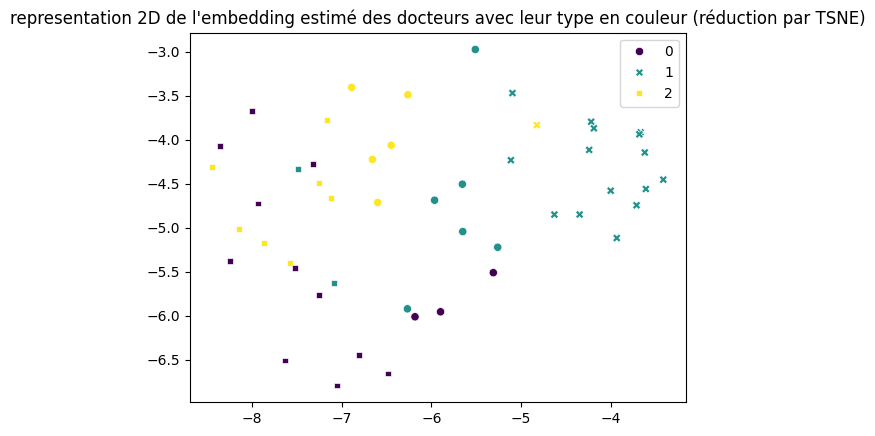

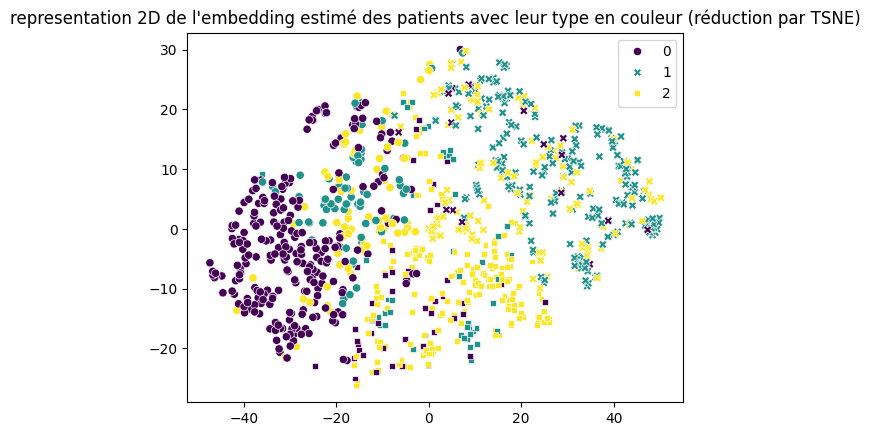

Temps d'exécution : 6 secondes


In [22]:
# Visualisation avec PCA des clusters estimés
plot_functions.plot_ef_RD(graph_object = graph_object, 
                   ef_patient = ef_patient_hat, 
                   ef_doctor= ef_doctor_hat,
                   RD_method = "TSNE" ,
                   save = False,
                   label_doctor = cluster_doctor_hat,
                   label_patient = cluster_patient_hat) 

In [23]:
metric_doctor_hat =  metrics.adjusted_rand_score(graph_object.psi_class, cluster_doctor_hat)
print(f"AMI du clustering sur l'embedding estimé des docteurs: {metric_doctor_hat}")
metric_patient_hat =   metrics.adjusted_rand_score(graph_object.alpha_class, cluster_patient_hat)
print(f"AMI du clustering sur l'embedding estimé des patients: {metric_patient_hat}")

AMI du clustering sur l'embedding estimé des docteurs: 0.2628756918822632
AMI du clustering sur l'embedding estimé des patients: 0.22562934839252563


### Robustesse

Pour Evaluer la robustesse de l'embedding estimé, nous allons, 100 fois, prendre 80% des data aléatoirement et les fournir au modèle. Ensuite, pour chaque simulation nous construisons une matrice des distances euclidiennes $A_{k}$ où la composante $a_{ij}$ vaut la distance euclidienne entre $\alpha_{i}$ et $\alpha_{j}$ (ou entre $\psi_{i}$ et $\psi_{j}$).
Puis, nous formons un nouvelle matrice B de taille 100 x 100 où la composante $b_{ij}$ vaut la cosine similarity entre les matrices $A_{i}$ et $A_{j}$. Enfin, nous prenons la moyenne pour avoir une idée de la robustesse.

In [ ]:
simulation.robustesse_all(100, 0.8, graph_object, nb_epochs = 60, dim_embedding = 5,  algorithm = "MF")

simulation 1: done
simulation 2: done
simulation 3: done
simulation 4: done
simulation 5: done
simulation 6: done
simulation 7: done
simulation 8: done
simulation 9: done
simulation 10: done
simulation 11: done
simulation 12: done
simulation 13: done
simulation 14: done
simulation 15: done
simulation 16: done
simulation 17: done
simulation 18: done
simulation 19: done
simulation 20: done
simulation 21: done
simulation 22: done
simulation 23: done
simulation 24: done
simulation 25: done
simulation 26: done
simulation 27: done
simulation 28: done
simulation 29: done
simulation 30: done
simulation 31: done
simulation 32: done
simulation 33: done
simulation 34: done
simulation 35: done
simulation 36: done
simulation 37: done
simulation 38: done
simulation 39: done
simulation 40: done
simulation 41: done
simulation 42: done
simulation 43: done
simulation 44: done
simulation 45: done
simulation 46: done
simulation 47: done
simulation 48: done
simulation 49: done
simulation 50: done
simulatio

### Essaie avec contrainte de la sphère

In [29]:
# Training
estimates = get_estimations(graph_object.df, nb_epochs=50, show_print=0, dim_embedding=5, constraint = "sphere")

# Recuperation des poids au niveau des embeddings
ef_patient_hat = estimates[1][0]
ef_doctor_hat = estimates[1][1]

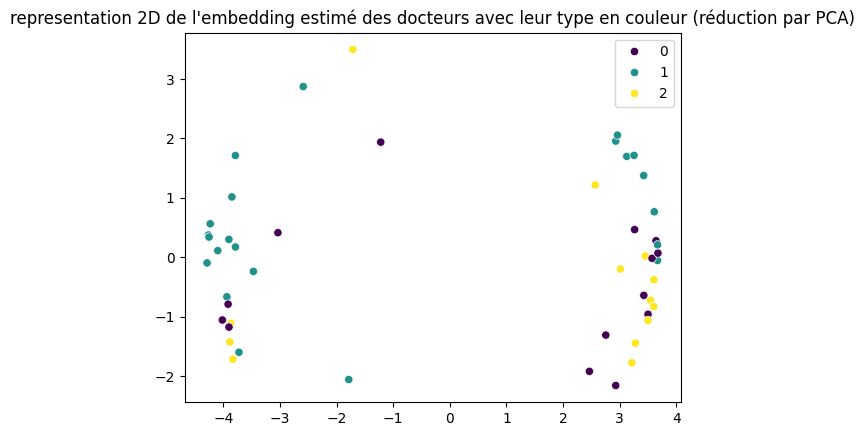

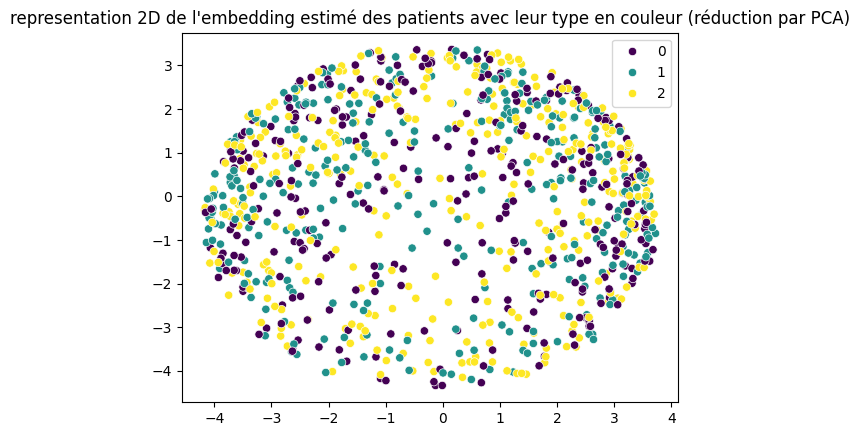

Temps d'exécution : 0 secondes


In [30]:
d# Temps d'exécution : 0 secondes
plot_functions.plot_ef_RD(graph_object = graph_object, ef_patient = ef_patient_hat, ef_doctor= ef_doctor_hat, RD_method = "PCA" , save = False)

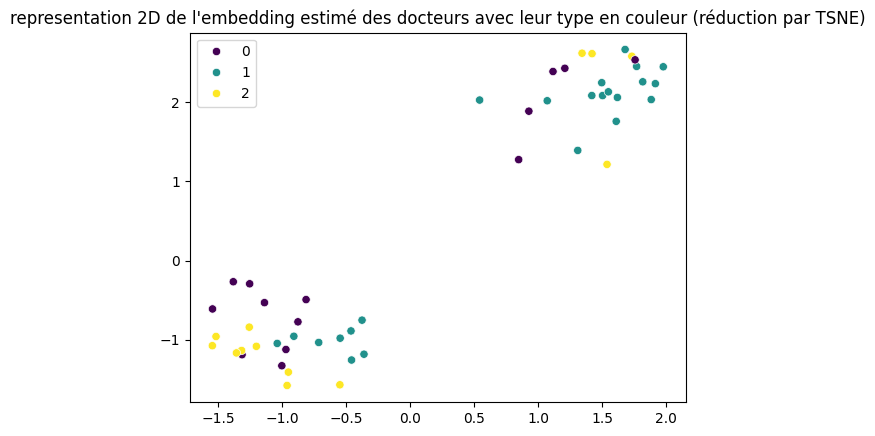

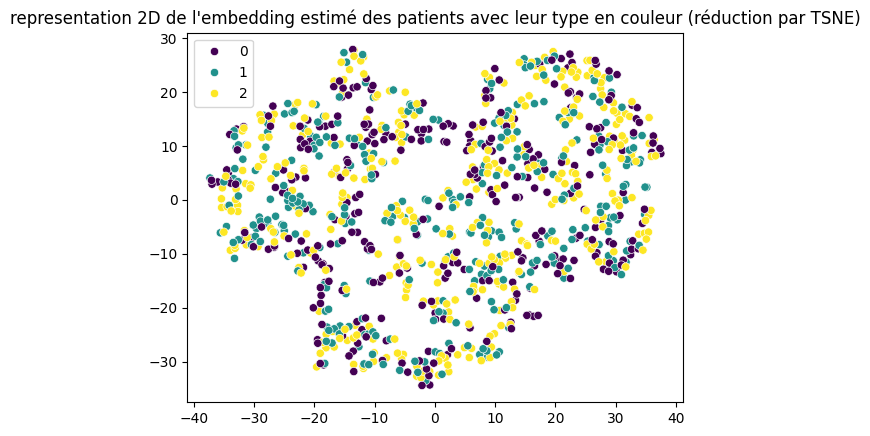

Temps d'exécution : 5 secondes


In [31]:
# Temps d'exécution : 0 secondes
plot_functions.plot_ef_RD(graph_object = graph_object, ef_patient = ef_patient_hat, ef_doctor= ef_doctor_hat, RD_method = "TSNE" ,save = False)